<a href="https://colab.research.google.com/github/EmePin/Analisis-de-datos/blob/main/Analisis_PLANEA_MS_2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANÁLISIS DE DATOS PLANEA MS 2017



Este cuaderno presenta un análisis exploratorio de la base de datos de PLANEA (Plan Nacional para la Evaluación de los Aprendizajes) 2017 para la evaluación de Educación Media Superior. PLANEA  es un conjunto de pruebas estandarizadas diseñadas para medir el logro académico de los estudiantes en México en distintas áreas del conocimiento. Los datos utilizados en este análisis fueron obtenidos del sitio oficial: http://planea.sep.gob.mx/ms/base_de_datos_2017/


In [43]:
import pandas as pd  # Manejo y análisis de datos tabulares (DataFrames)
import os  # Interacción con el sistema operativo (archivos, directorios)
import matplotlib.pyplot as plt  # Creación de gráficos y visualizaciones básicas
import seaborn as sns  # Visualizaciones estadísticas avanzadas y estilizadas
import numpy as np  # Funciones matemáticas y numéricas para trabajar con arrays y realizar operaciones eficientes

## Recolección de datos

In [44]:

from google.colab import files
from google.colab import drive
# Montar Google Drive (si los archivos están ahí)
drive.mount('/content/drive')

# Ruta de la carpeta en Google Drive donde están los archivos Excel
folder_path = "/content/drive/MyDrive/COLAB DB/PLANEA_2017"
output_file = "/content/drive/MyDrive/COLAB DB/base_datos_unida.xlsx"

# Obtener lista de archivos Excel en la carpeta
files = [f for f in os.listdir(folder_path) if f.endswith(".xlsx")]

# Lista para almacenar los DataFrames
dataframes = []

# Leer y unir todos los archivos
for file in files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_excel(file_path)
    dataframes.append(df)

# Concatenar todos los DataFrames en uno solo
df_combined = pd.concat(dataframes, ignore_index=True)

# Guardar en un nuevo archivo Excel
df_combined.to_excel(output_file, index=False)

print(f"Archivo combinado guardado como {output_file}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo combinado guardado como /content/drive/MyDrive/COLAB DB/base_datos_unida.xlsx


### Set de datos

In [45]:
df = pd.read_excel("/content/drive/MyDrive/COLAB DB/base_datos_unida.xlsx")


In [46]:
print(df.shape)
df.head()

(16380, 52)


,CLAVE DE LA ENTIDAD,ENTIDAD,CLAVE DE LA ESCUELA,NOMBRE DE LA ESCUELA,TURNO,EXTENSION,NOMBRE DEL MUNICIPIO,NOMBRE DE LA LOCALIDAD,SUBSISTEMA,GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT,...,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ESCUELAS PARECIDAS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ESCUELAS PARECIDAS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ESCUELAS PARECIDAS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ESCUELAS PARECIDAS,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS I,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS II,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS III,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS IV
0,16,MICHOACAN,16UBH0014H,ESC. PREP. ISAAC ARRIAGA,MATUTINO,NaN,MORELIA,MORELIA,BACHI AUTONOMO,MUY BAJO,...,11.6,2.3,62.2,28.2,7.4,2.2,66.2,23.3,8,2.5
1,16,MICHOACAN,16UBH0014H,ESC. PREP. ISAAC ARRIAGA,VESPERTINO,NaN,MORELIA,MORELIA,BACHI AUTONOMO,MUY BAJO,...,12.5,0.0,62.2,28.2,7.4,2.2,66.2,23.3,8,2.5
2,16,MICHOACAN,16UBH0015G,ESC. PREP. GRAL. LAZARO CARDENAS,MATUTINO,NaN,URUAPAN,URUAPAN,BACHI AUTONOMO,BAJO,...,5.4,2.7,62.2,28.2,7.4,2.2,66.2,23.3,8,2.5
3,16,MICHOACAN,16UBH0015G,ESC. PREP. GRAL. LAZARO CARDENAS,VESPERTINO,NaN,URUAPAN,URUAPAN,BACHI AUTONOMO,BAJO,...,0.0,0.0,62.2,28.2,7.4,2.2,66.2,23.3,8,2.5
4,16,MICHOACAN,16UBH0019C,COLEGIO PRIMITIVO Y NACIONAL DE SAN NICOLAS DE...,MATUTINO,NaN,MORELIA,MORELIA,BACHI AUTONOMO,MUY BAJO,...,22.4,6.9,62.2,28.2,7.4,2.2,66.2,23.3,8,2.5


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16380 entries, 0 to 16379
Data columns (total 52 columns):
 #   Column                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                              --------------  -----  
 0   CLAVE DE LA ENTIDAD                                                                                                 16380 non-null  int64  
 1   ENTIDAD                                                                                                             16380 non-null  object 
 2   CLAVE DE LA ESCUELA                                                                                                 16380 non-null  object 
 3   NOMBRE DE LA ESCUELA                                                                                                16379 non-null  object 
 4   TURNO           

## Limpieza y transformación
Se realiza el proceso de limpieza teniendo en cuenta las situaciones más comunes:

1.- Datos faltantes

2.. Columnas irrelevantes para el problema a resolver

3.- Registros (Filas) repetidos

4.- Valores extremos (outliers)

5.- Errores tipográficos

### Datos faltantes

Alternativas:

- Eliminar
- Interpolar
- modelos de ML para completar

Mi solución: Eliminar la columna Extensión porque tiene muchas filas vacías y es irrelevante

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16380 entries, 0 to 16379
Data columns (total 52 columns):
 #   Column                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                              --------------  -----  
 0   CLAVE DE LA ENTIDAD                                                                                                 16380 non-null  int64  
 1   ENTIDAD                                                                                                             16380 non-null  object 
 2   CLAVE DE LA ESCUELA                                                                                                 16380 non-null  object 
 3   NOMBRE DE LA ESCUELA                                                                                                16379 non-null  object 
 4   TURNO           

In [49]:
# prompt: elimina de df la columna extensión

if 'EXTENSION' in df.columns:
  df = df.drop('EXTENSION', axis=1)


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16380 entries, 0 to 16379
Data columns (total 51 columns):
 #   Column                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                              --------------  -----  
 0   CLAVE DE LA ENTIDAD                                                                                                 16380 non-null  int64  
 1   ENTIDAD                                                                                                             16380 non-null  object 
 2   CLAVE DE LA ESCUELA                                                                                                 16380 non-null  object 
 3   NOMBRE DE LA ESCUELA                                                                                                16379 non-null  object 
 4   TURNO           

- Se eliminan los datos que no están completos al ver con .info() que no todas las columnas tienen la misma cantidad de registros.

In [51]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16345 entries, 0 to 16379
Data columns (total 51 columns):
 #   Column                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                              --------------  -----  
 0   CLAVE DE LA ENTIDAD                                                                                                 16345 non-null  int64  
 1   ENTIDAD                                                                                                             16345 non-null  object 
 2   CLAVE DE LA ESCUELA                                                                                                 16345 non-null  object 
 3   NOMBRE DE LA ESCUELA                                                                                                16345 non-null  object 
 4   TURNO                

### Eliminar columnas irrelevantes

*Conocer si una columna es relevante porque contiene subniveles

In [52]:


# Función para contar subniveles en una columna
def contar_subniveles(df, columna):
  subniveles_unicos = df[columna].unique()
  return len(subniveles_unicos)

# Diccionario para almacenar la cantidad de subniveles para cada columna
cantidad_subniveles = {}

# Iterar sobre las columnas del DataFrame
for columna in df.columns:
  cantidad_subniveles[columna] = contar_subniveles(df, columna)

# Mostrar la cantidad de subniveles para cada columna
print("Cantidad de subniveles para cada columna:")
for columna, cantidad in cantidad_subniveles.items():
  print(f"{columna}: {cantidad}")


Cantidad de subniveles para cada columna:
CLAVE DE LA ENTIDAD: 32
ENTIDAD: 32
CLAVE DE LA ESCUELA: 14634
NOMBRE DE LA ESCUELA: 12674
TURNO: 4
NOMBRE DEL MUNICIPIO: 2097
NOMBRE DE LA LOCALIDAD: 7288
SUBSISTEMA: 21
GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT: 5
SOSTENIMIENTO: 4
TOTAL DE ALUMNOS EN EL ULTIMO GRADO MATRICULA: 566
ALUMNOS  PROGRAMADOS: 42
ALUMNOS EVALUADOS LENGUAJE Y COMUNICACION: 80
ALUMNOS EVALUADOS MATEMATICAS: 80
PORCENTAJE DE ALUMNOS EVALUADOS LENGUAJE Y COMUNICACIÓN: 382
PORCENTAJE DE ALUMNOS EVALUADOS MATEMATICAS: 384
LOS ALUMNOS EVALUADOS SON REPRESENTATIVOS DE LA TOTALIDAD DE LOS ESTUDIANTES DE LA ESCUELA LENGUAJE Y COMUNICACION: 2
LOS ALUMNOS EVALUADOS SON REPRESENTATIVOS DE LA TOTALIDAD DE LOS ESTUDIANTES DE LA ESCUELA MATEMATICAS: 2
ESCUELAS PARECIDAS PARA COMPARACION: 116
NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I CANTIDAD DE ALUMNOS: 74
NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II CANTIDAD DE ALUMNOS: 43
NIVELES DE LOGRO EN LENGUAJE Y

In [53]:
df.describe()

,CLAVE DE LA ENTIDAD,TOTAL DE ALUMNOS EN EL ULTIMO GRADO MATRICULA,ALUMNOS PROGRAMADOS,ALUMNOS EVALUADOS LENGUAJE Y COMUNICACION,ALUMNOS EVALUADOS MATEMATICAS,PORCENTAJE DE ALUMNOS EVALUADOS LENGUAJE Y COMUNICACIÓN,PORCENTAJE DE ALUMNOS EVALUADOS MATEMATICAS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I CANTIDAD DE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II CANTIDAD DE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III CANTIDAD DE ALUMNOS,...,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ESCUELAS PARECIDAS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ESCUELAS PARECIDAS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ESCUELAS PARECIDAS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ESCUELAS PARECIDAS,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS I,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS II,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS III,PORCENTAJE DE ALUMNOS EN TODAS LAS ESCUELAS DE MÉXICO EN NIVELES DE LOGRO EN MATEMATICAS IV
count,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,...,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,16345.000000,1.634500e+04,1.634500e+04,16345.0,16345.0
mean,17.486265,75.075130,39.939737,34.725237,34.389783,87.538079,86.946265,11.856103,9.722973,9.639890,...,8.148113,3.841089,67.141664,22.533735,7.764576,2.557963,6.620000e+01,2.330000e+01,8.0,2.5
std,8.291699,104.953593,26.821827,23.845844,23.656874,13.880695,14.492409,10.838922,7.829441,9.256139,...,11.438348,9.605274,10.051083,5.037076,3.985147,2.246845,2.002371e-11,6.928004e-12,0.0,0.0
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.300000,1.300000,0.000000,0.000000,0.000000,...,0.000000,0.000000,10.000000,8.900000,1.800000,0.000000,6.620000e+01,2.330000e+01,8.0,2.5
25%,11.000000,17.000000,17.000000,15.000000,15.000000,83.300000,82.500000,4.000000,4.000000,3.000000,...,0.000000,0.000000,63.200000,20.100000,5.000000,1.000000,6.620000e+01,2.330000e+01,8.0,2.5
50%,16.000000,35.000000,35.000000,29.000000,29.000000,91.300000,90.900000,9.000000,7.000000,6.000000,...,4.200000,0.000000,67.200000,23.000000,7.200000,1.800000,6.620000e+01,2.330000e+01,8.0,2.5
75%,24.000000,94.000000,76.000000,59.000000,57.000000,97.100000,96.900000,17.000000,14.000000,14.000000,...,11.500000,3.700000,73.500000,24.600000,9.500000,3.900000,6.620000e+01,2.330000e+01,8.0,2.5
max,32.000000,2696.000000,80.000000,80.000000,80.000000,100.000000,103.100000,78.000000,48.000000,53.000000,...,100.000000,100.000000,88.500000,45.900000,38.200000,19.000000,6.620000e+01,2.330000e+01,8.0,2.5


### Eliminar filas repetidas

In [54]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df.shape}')

Tamaño del set antes de eliminar las filas repetidas: (16345, 51)
Tamaño del set después de eliminar las filas repetidas: (16345, 51)


### Detección y manejo de valores extremos

El uso de gráficos de caja (o «boxplots») es una herramienta que fácilmente permite detectar la presencia de «outliers» en variables numéricas.

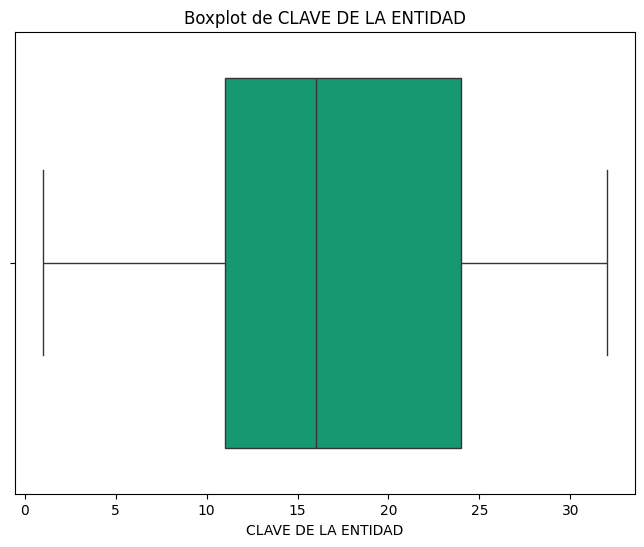

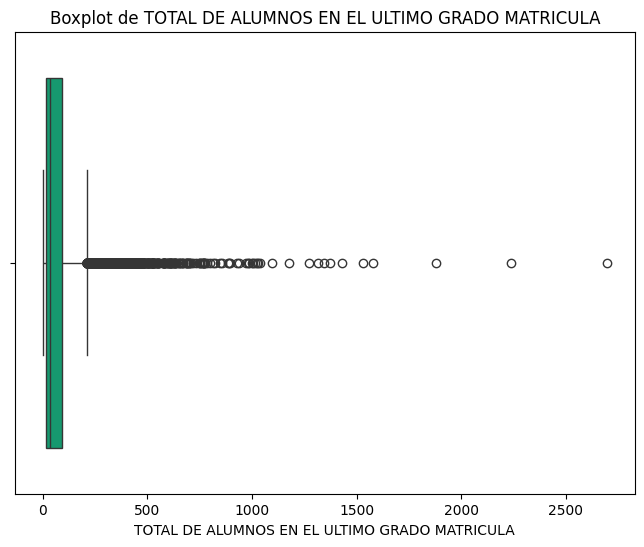

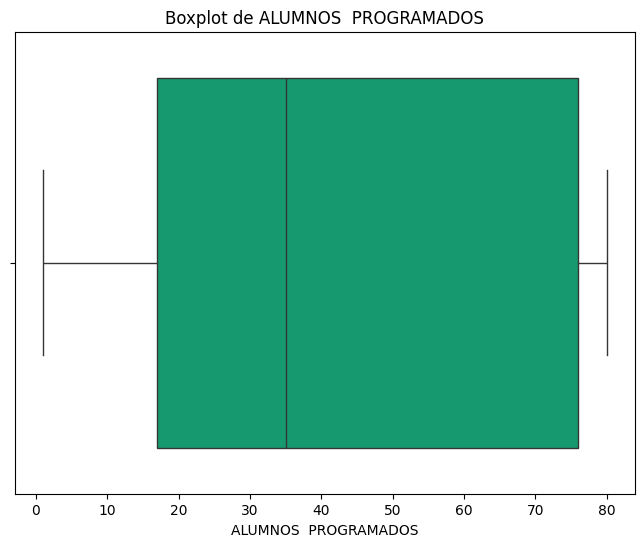

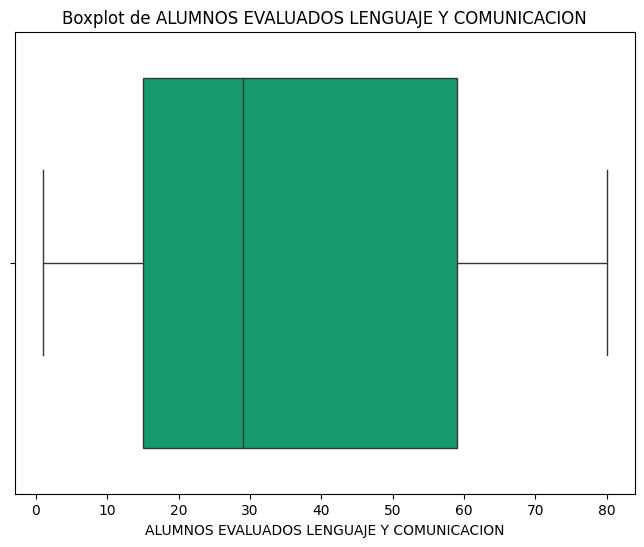

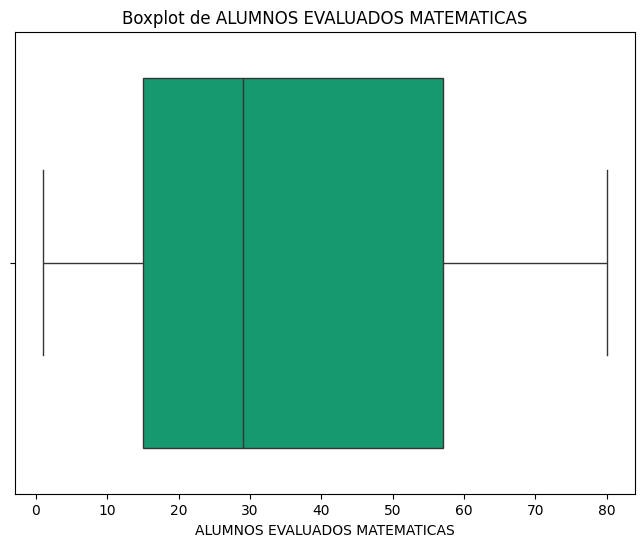

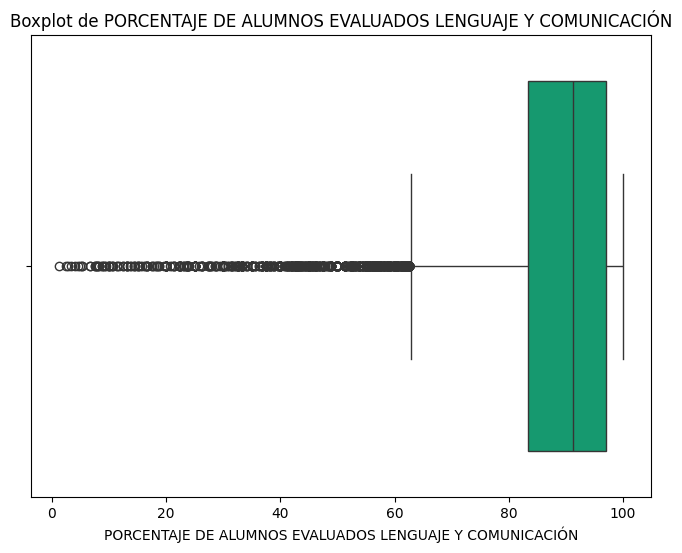

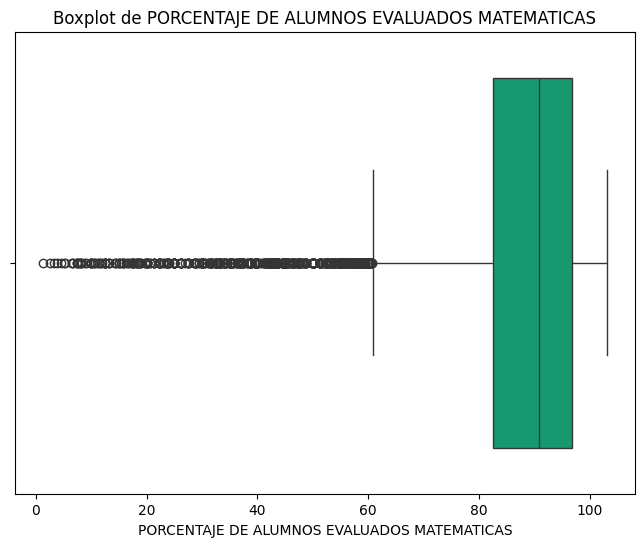

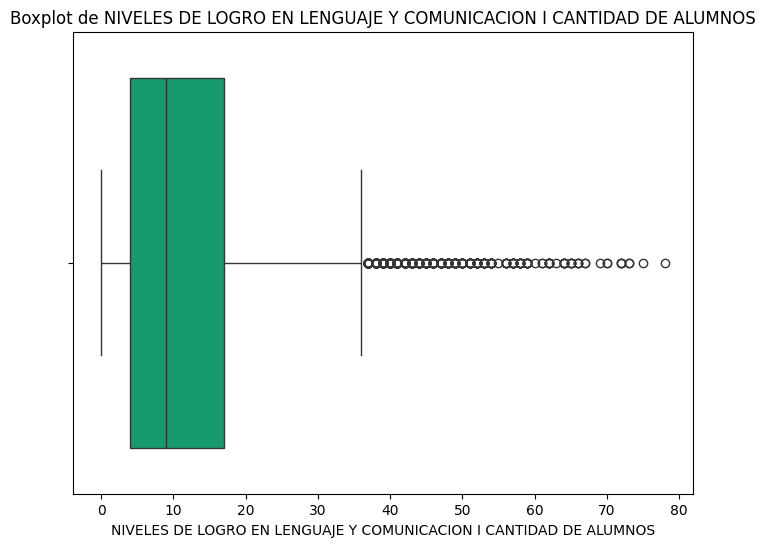

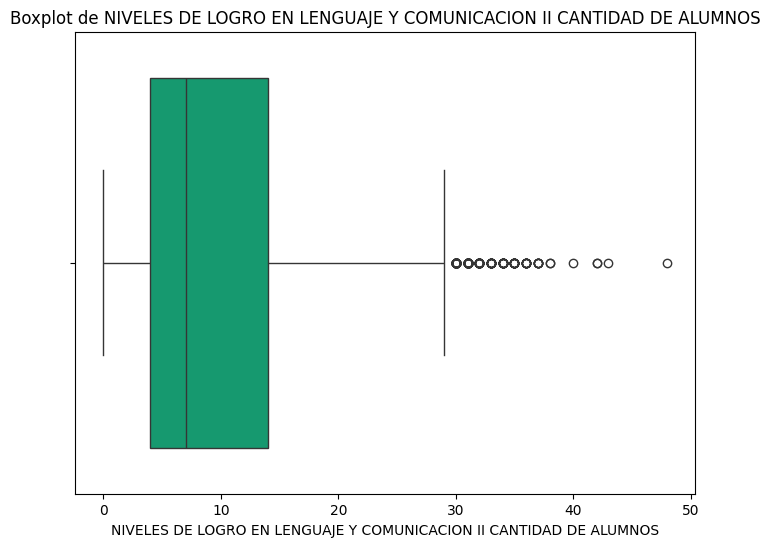

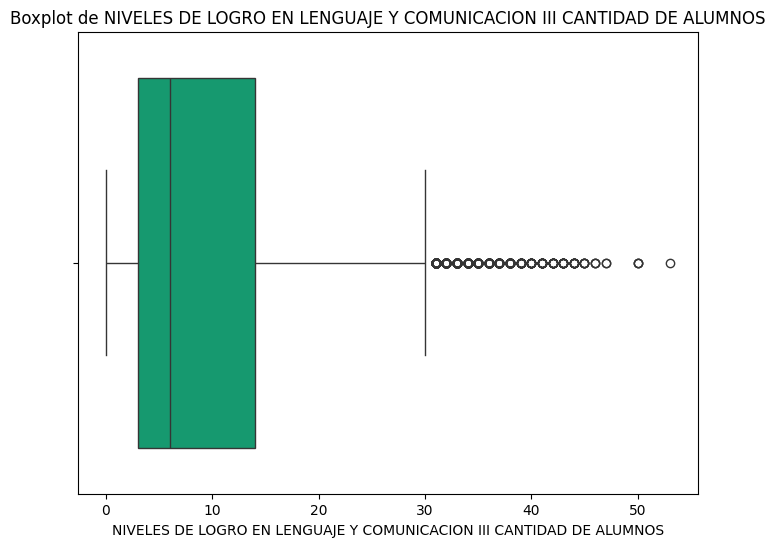

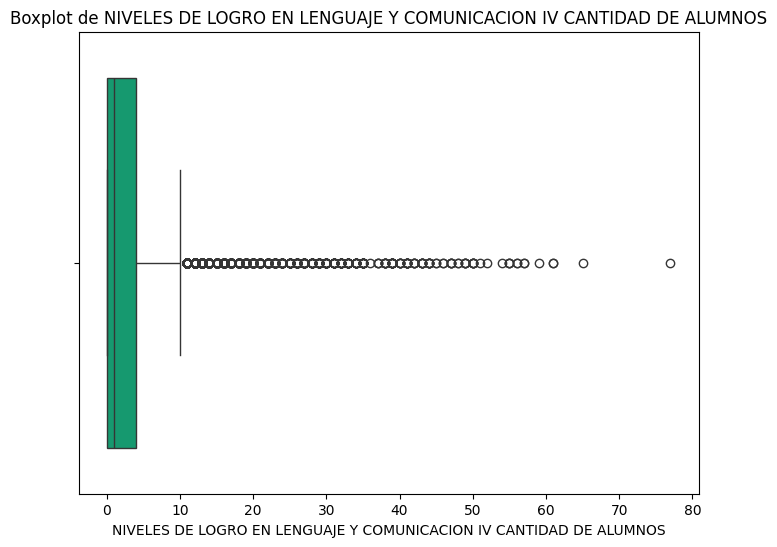

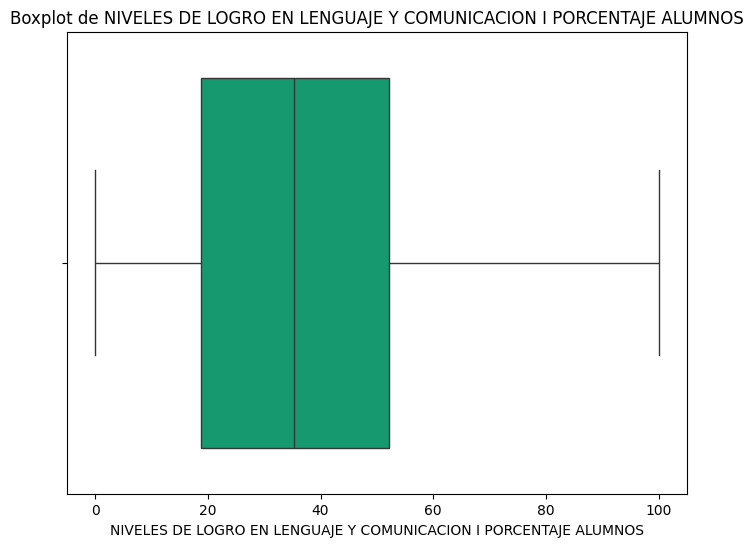

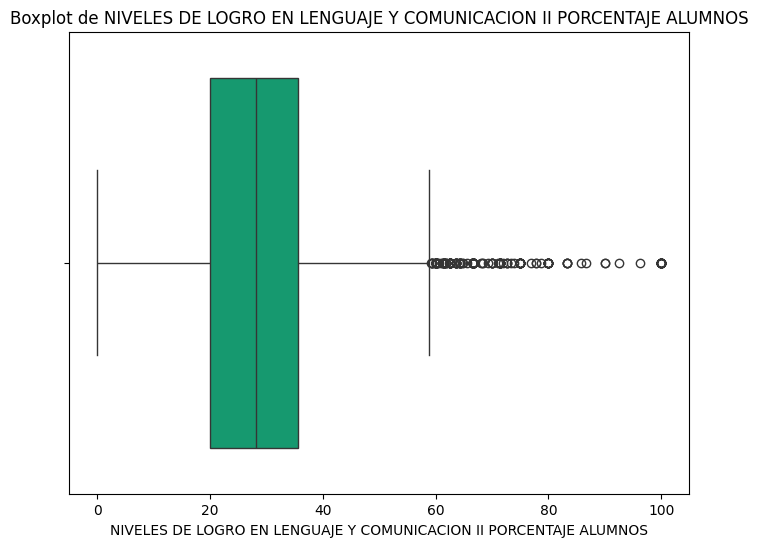

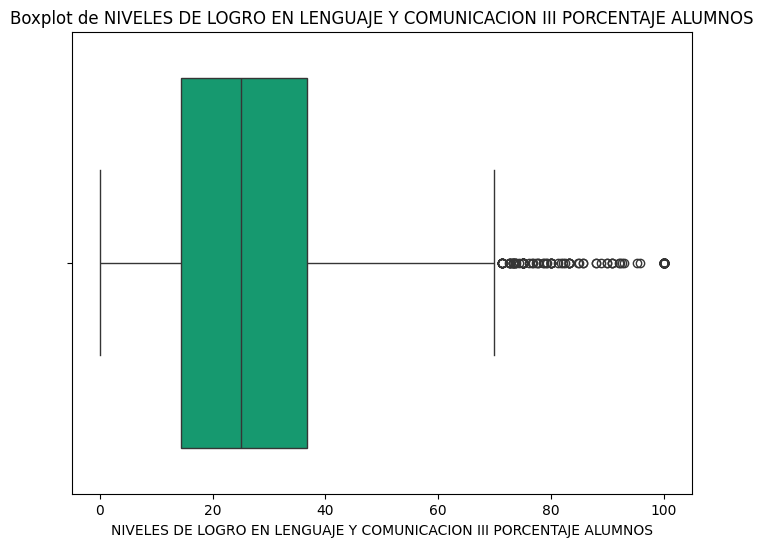

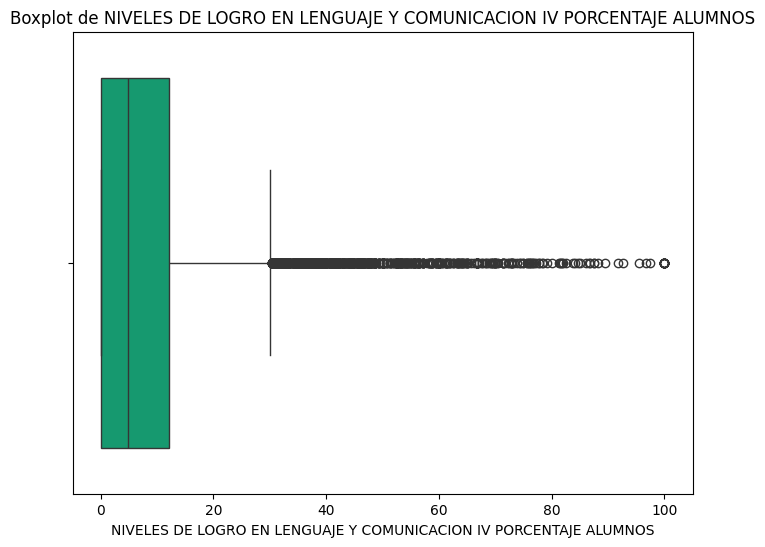

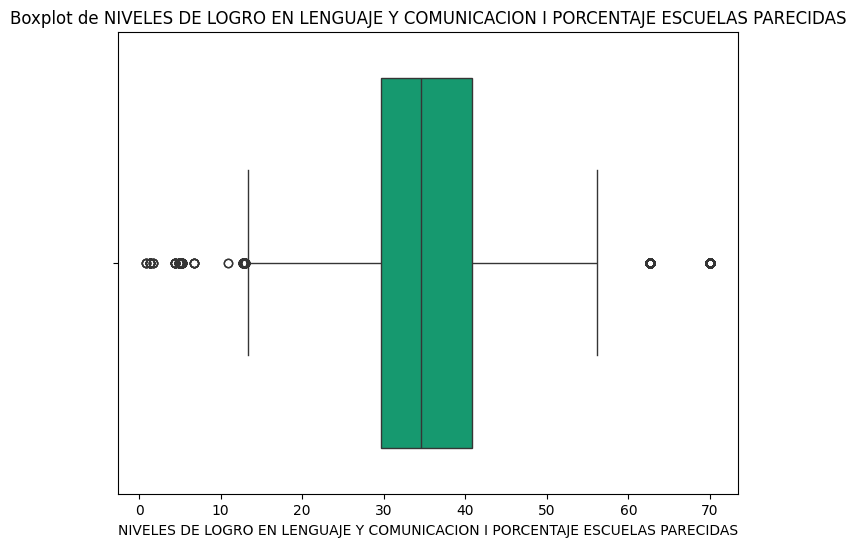

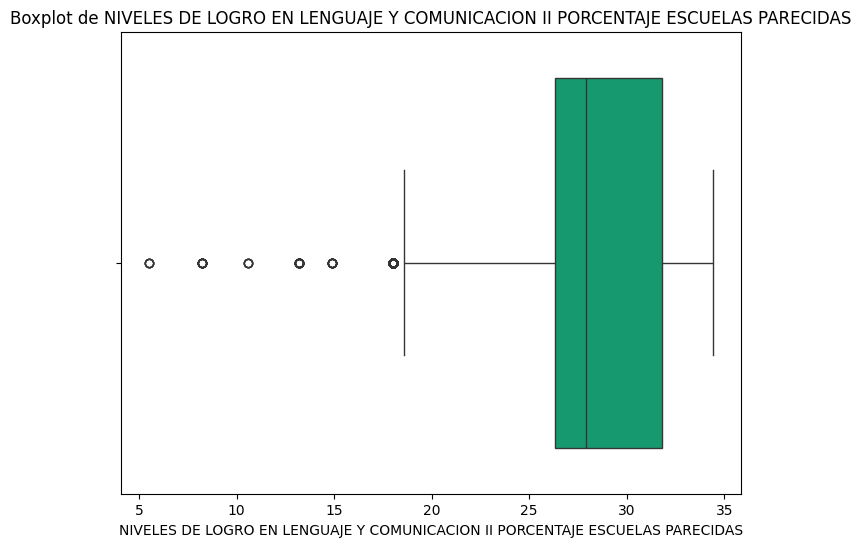

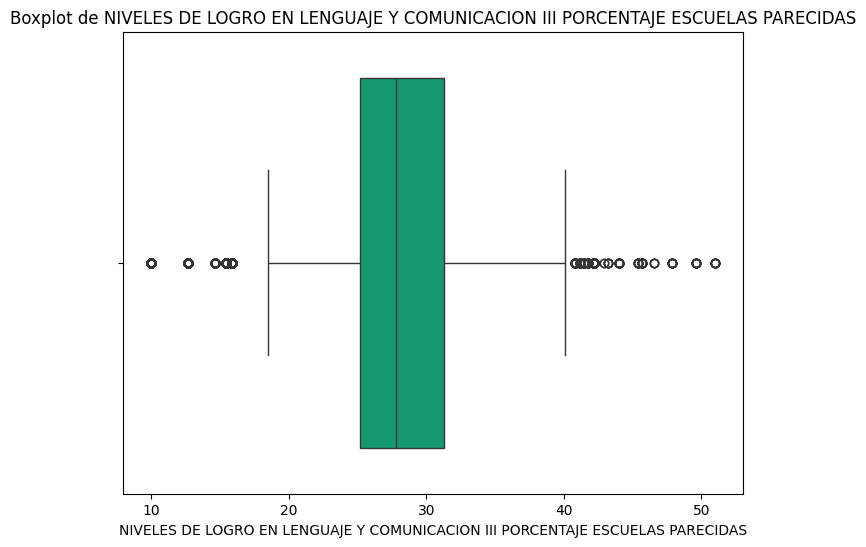

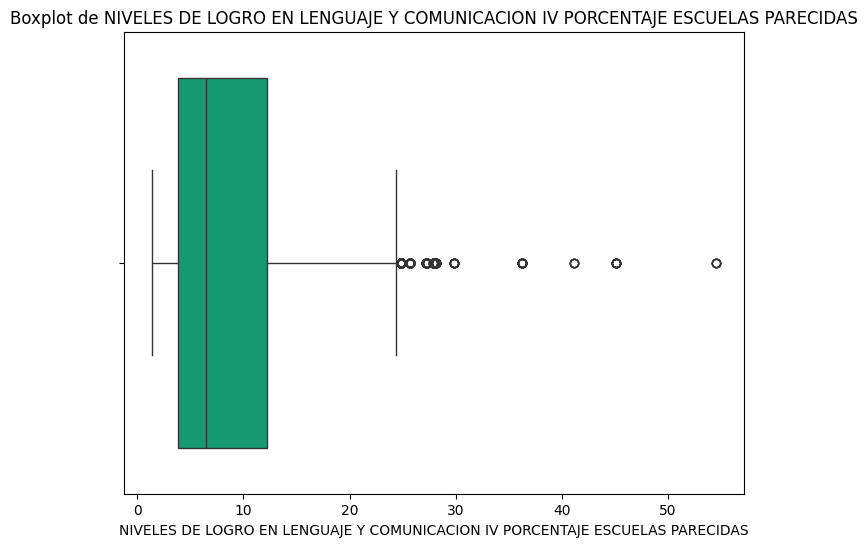

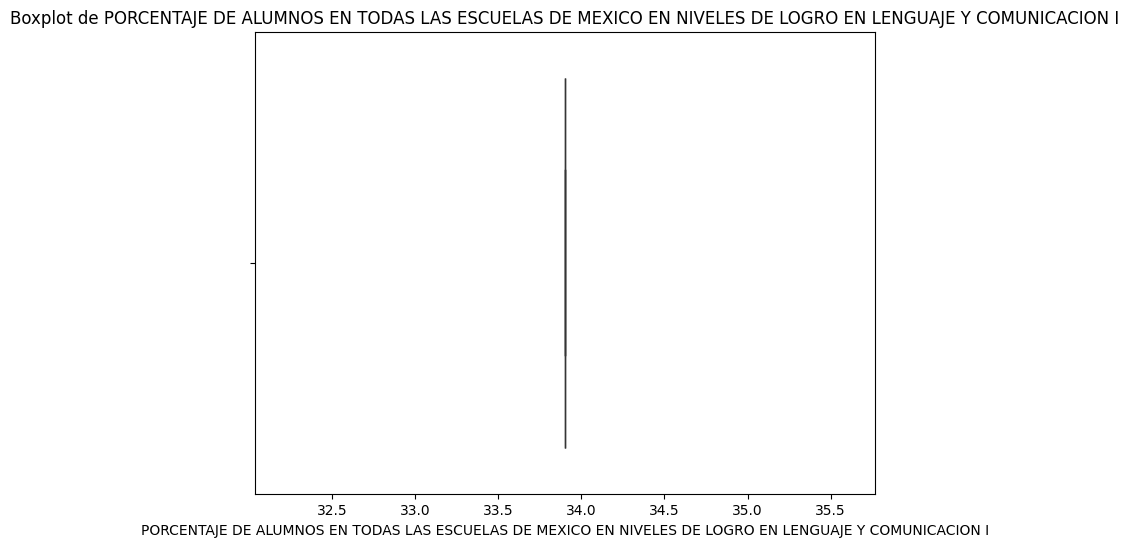

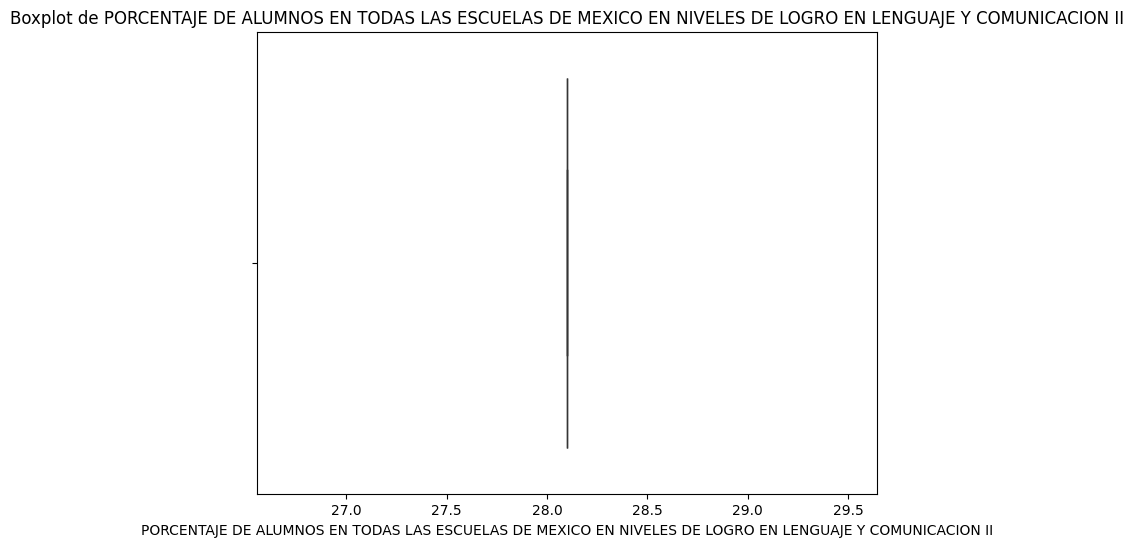

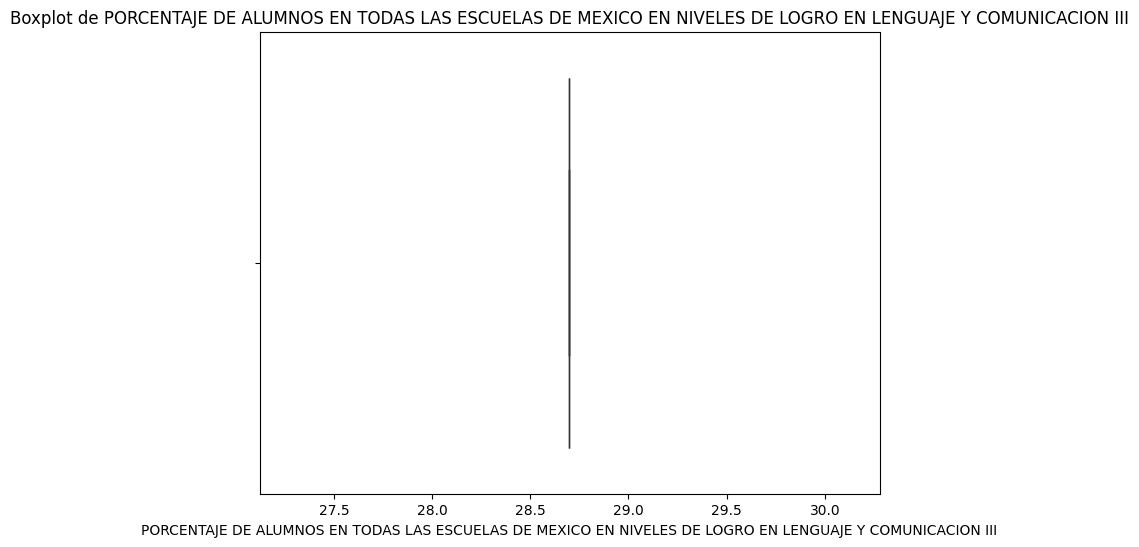

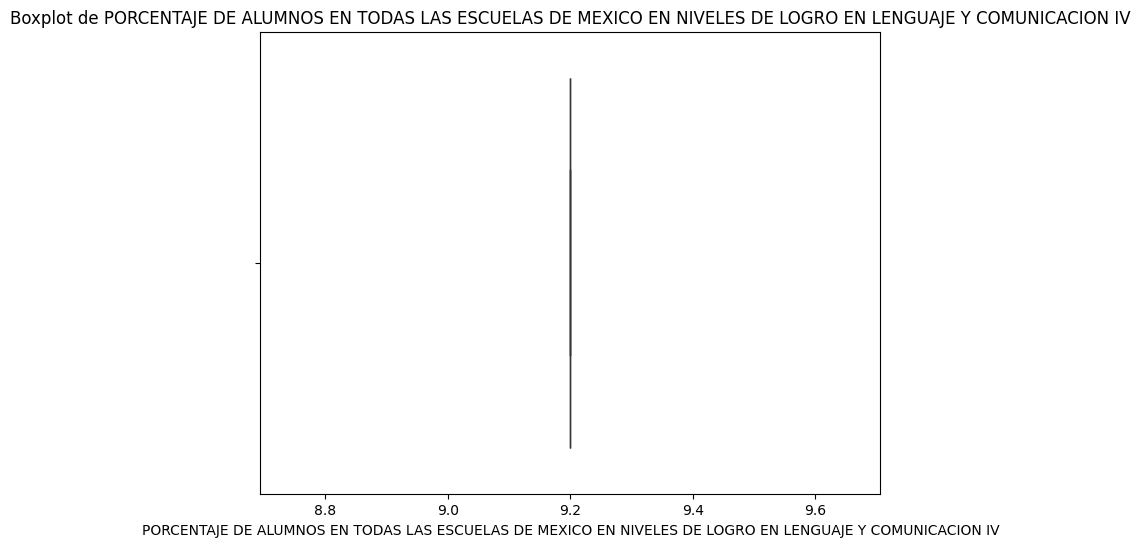

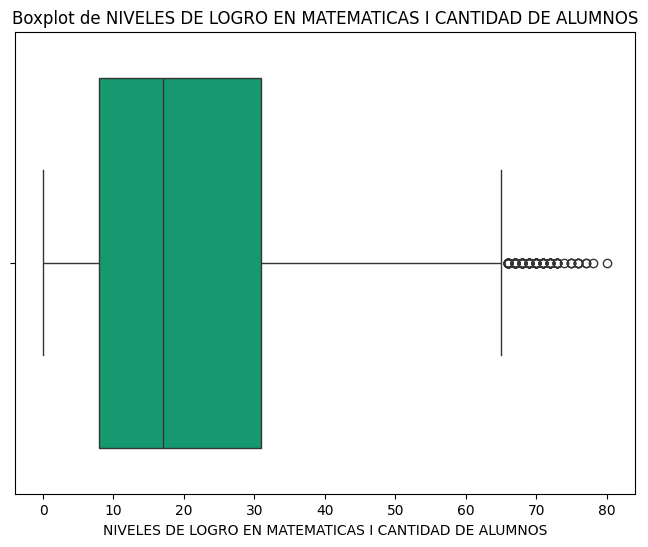

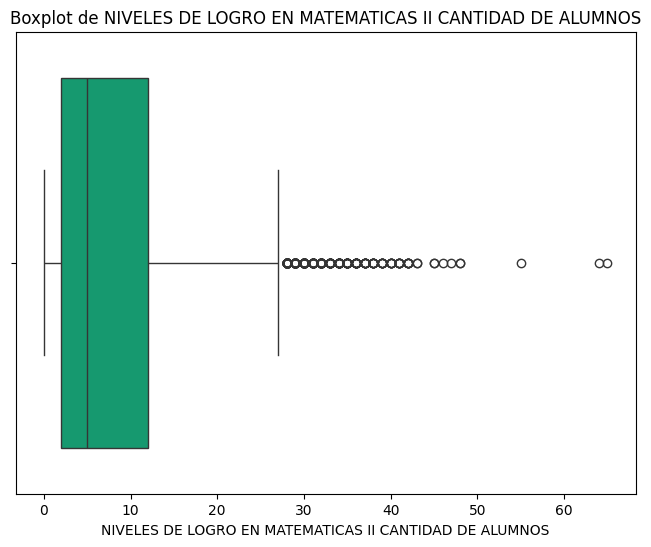

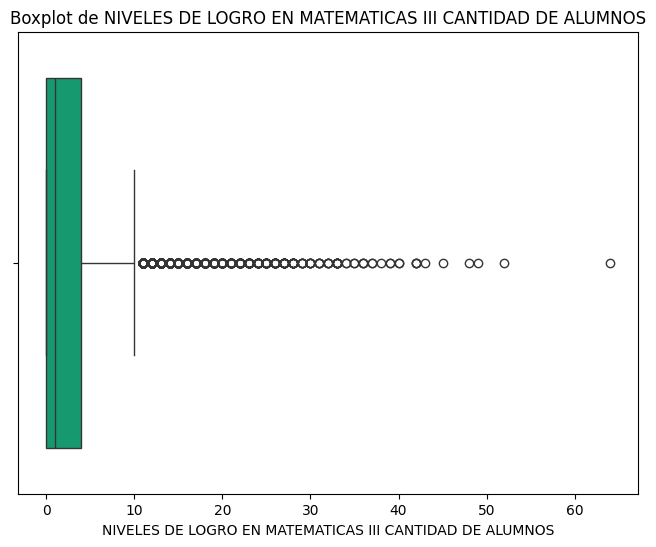

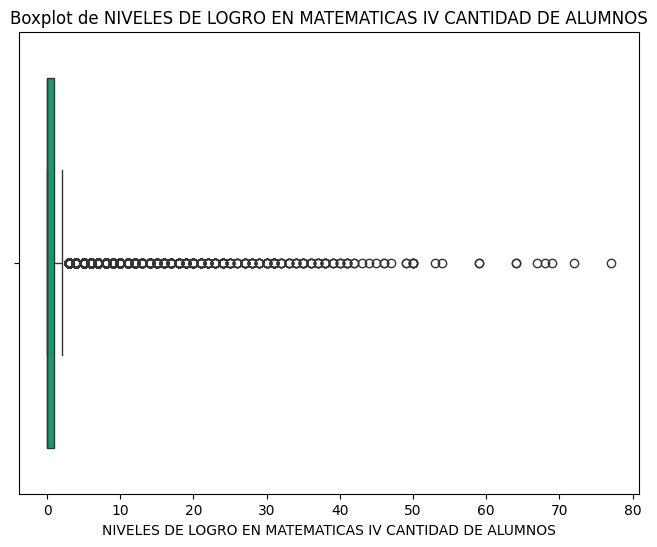

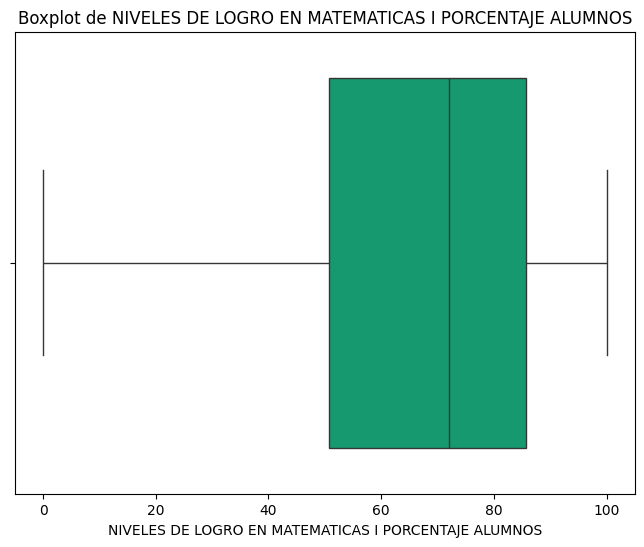

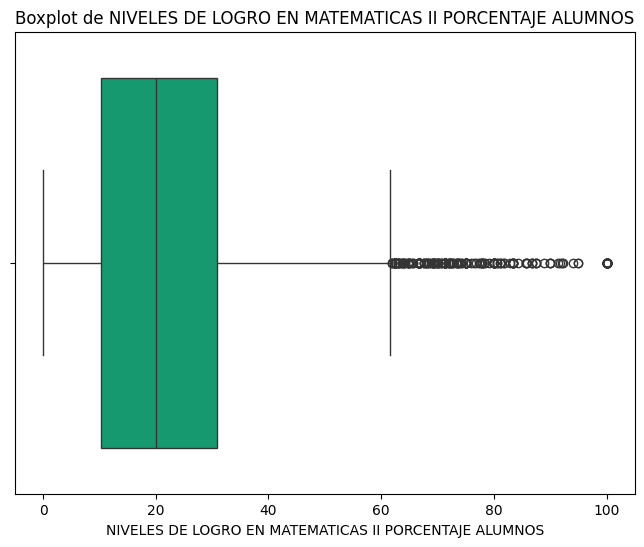

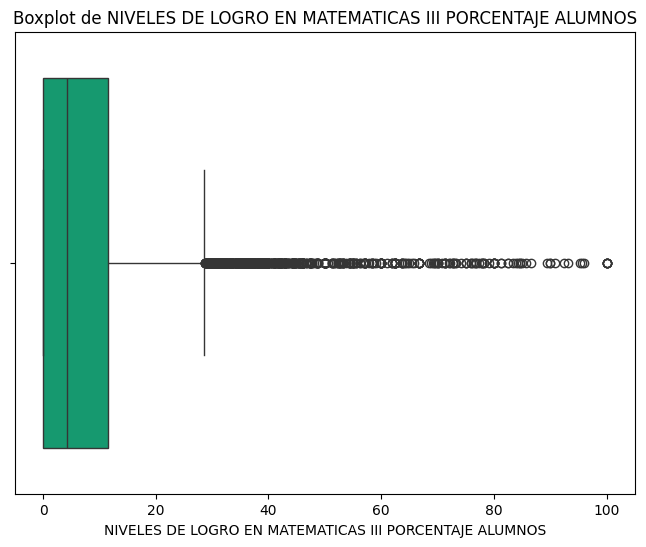

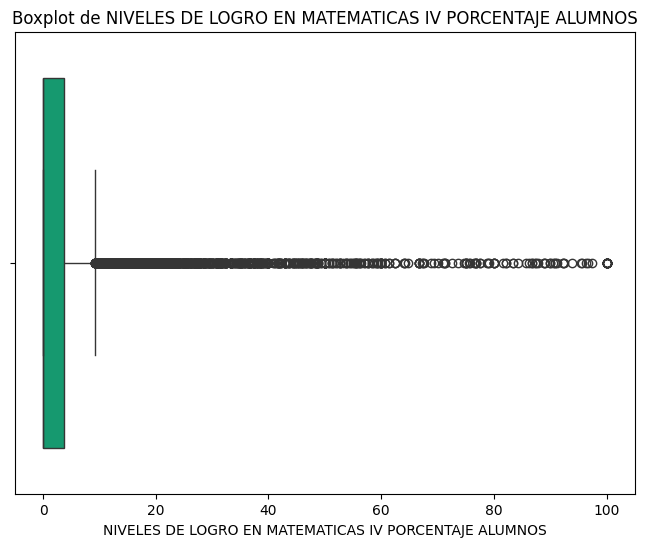

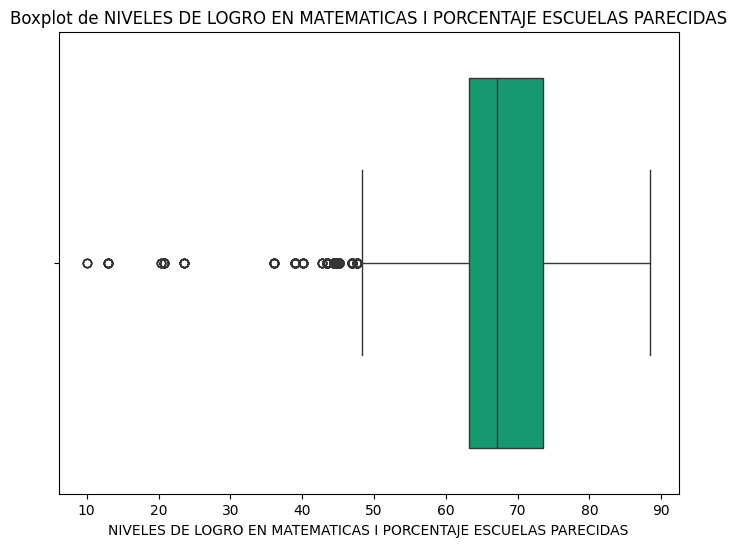

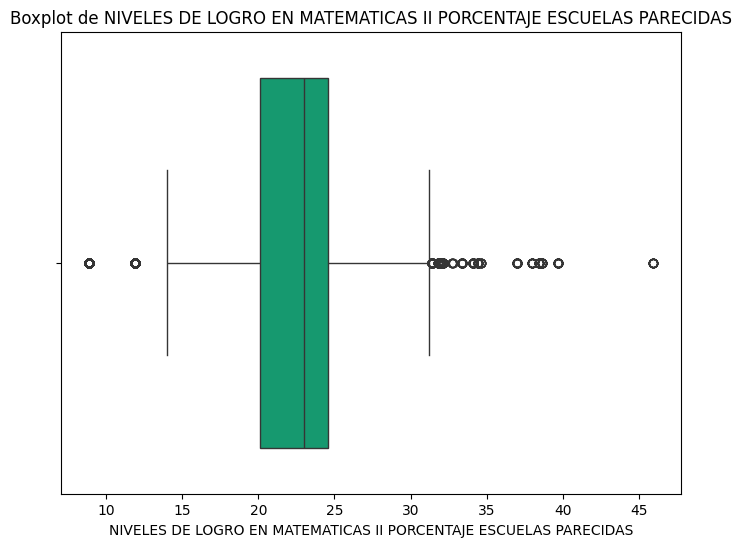

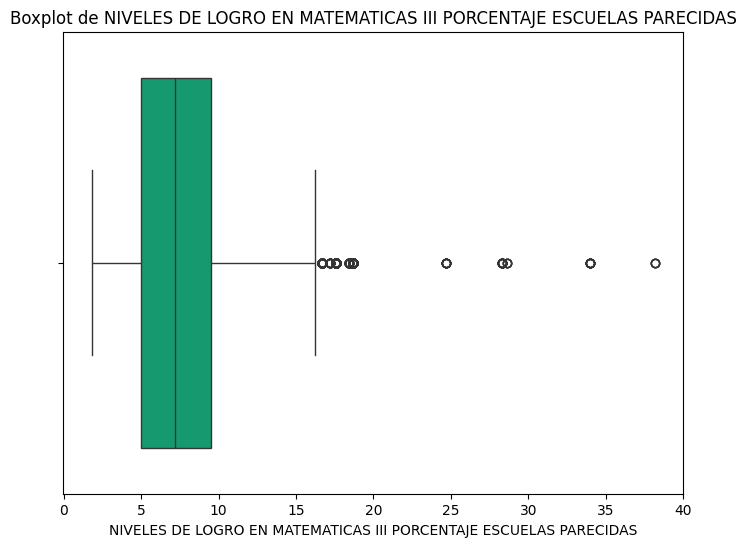

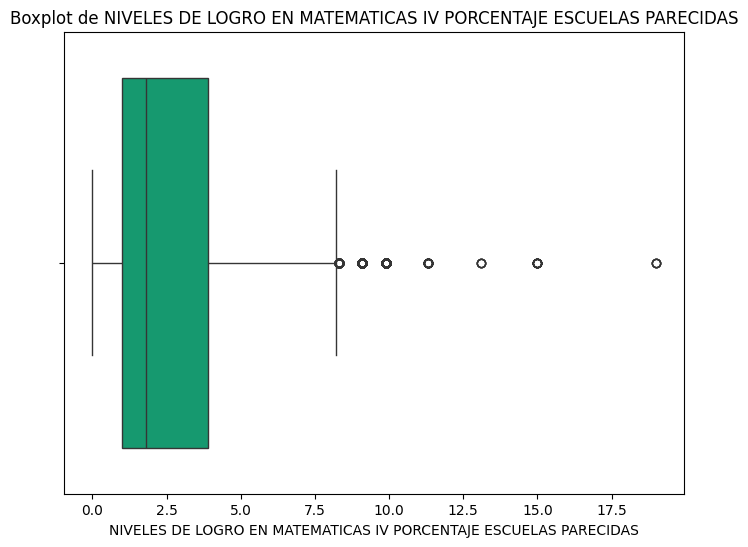

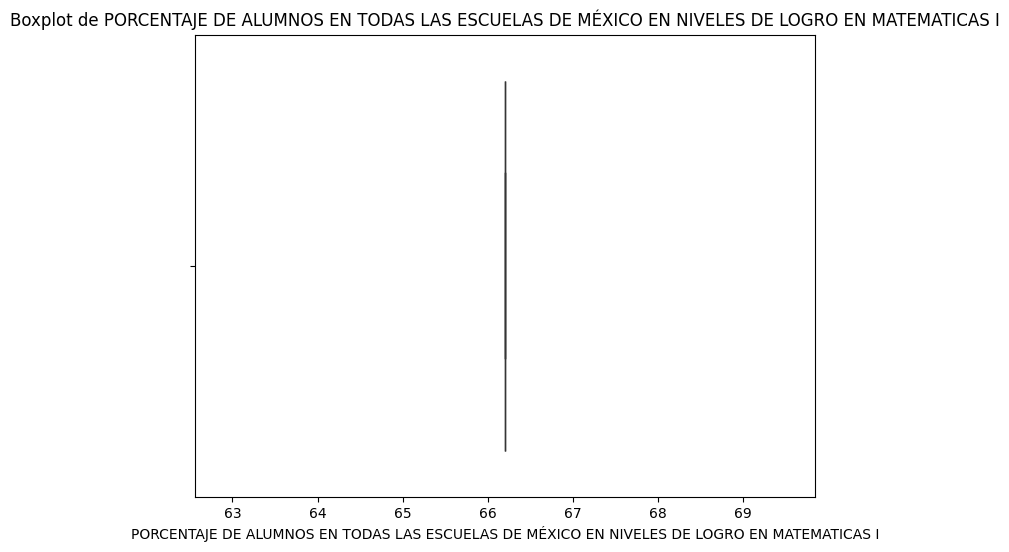

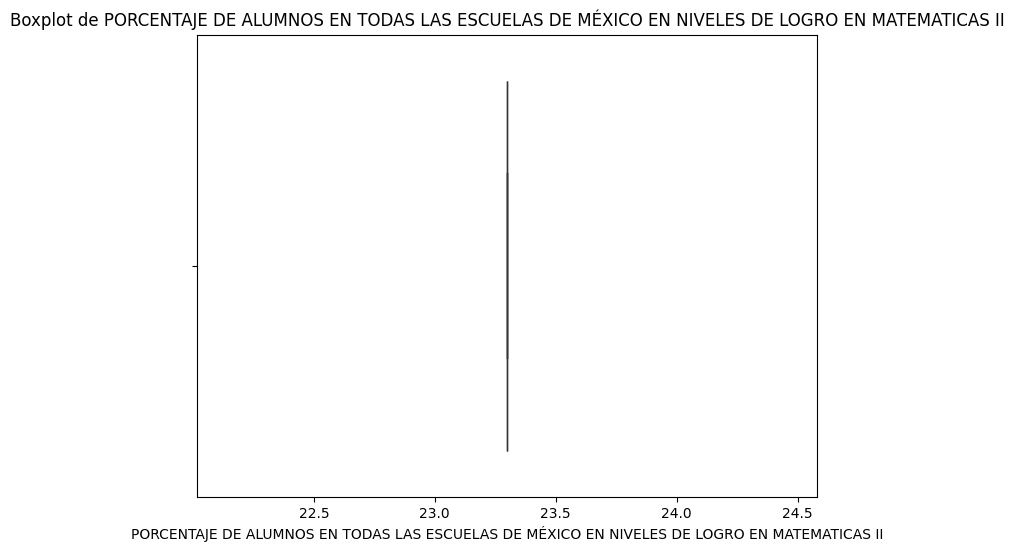

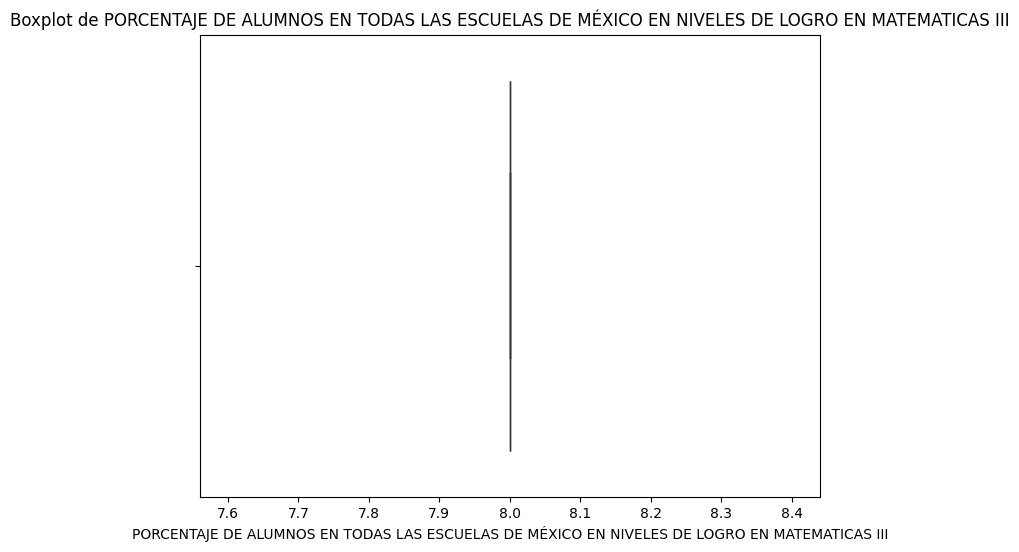

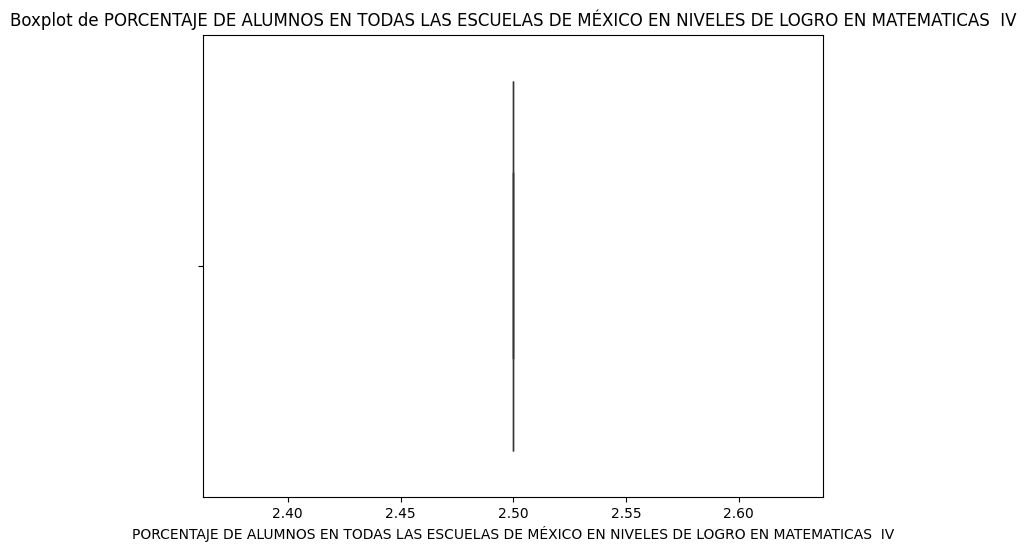

In [55]:

# Generar boxplots para cada columna numérica con color verde
for columna in df.select_dtypes(include=np.number).columns:
  plt.figure(figsize=(8, 6))
  sns.boxplot(x=df[columna], color='#00af77')
  plt.title(f'Boxplot de {columna}')
  plt.show()


### Errores tipográficos

Los errores tipográficos pueden corresponder a sub-niveles dentro de una variable categórica que estén escritos incorrectamente. Por ejemplo, podríamos tener un nivel como «mobile» en la variable «contact» y un sub-nivel similar pero escrito incorrectamente, como por ejemplo «mobiiile».

In [56]:

# Iterar sobre las columnas del DataFrame
for columna in df.columns:
  # Imprimir el nombre de la columna
  print(f"Columna: {columna}")

  # Usar value_counts() para obtener los subniveles y sus frecuencias
  subniveles = df[columna].value_counts()

  # Imprimir los subniveles y sus frecuencias
  print(subniveles)
  print("-" * 20)  # Separador entre columnas


Columna: CLAVE DE LA ENTIDAD
CLAVE DE LA ENTIDAD
15    1783
30    1640
21    1582
11     934
14     818
7      743
20     626
12     597
16     562
13     490
5      486
8      477
24     457
25     426
9      421
28     397
19     370
2      363
31     351
27     336
26     324
10     286
32     270
22     259
17     220
1      214
23     204
29     188
18     162
4      134
6      116
3      109
Name: count, dtype: int64
--------------------
Columna: ENTIDAD
ENTIDAD
MEXICO                 1783
VERACRUZ               1640
PUEBLA                 1582
GUANAJUATO              934
JALISCO                 818
CHIAPAS                 743
OAXACA                  626
GUERRERO                597
MICHOACAN               562
HIDALGO                 490
COAHUILA                486
CHIHUAHUA               477
SAN LUIS POTOSI         457
SINALOA                 426
CIUDAD DE MEXICO        421
TAMAULIPAS              397
NUEVO LEON              370
BAJA CALIFORNIA         363
YUCATAN                

La solución podría ser unificar subniveles por ejemplo todo mayuscula o todo sin acento

## Análisis y Visualización de datos

In [57]:
# Definir las métricas y las columnas a agrupar
nivel_logro_lenguaje = [
    "NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS",
    "NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS",
    "NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS",
    "NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS"
]

nivel_logro_matematicas = [
    "NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS",
    "NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS",
    "NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS",
    "NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS"
]

### A nivel Nacional

• Lenguaje y comunicación


o Porcentaje de estudiantes en cada nivel de logro por tipo de
sostenimiento.

o Porcentaje de estudiantes en cada nivel de logro por subsistema.

o Porcentaje de estudiantes en cada nivel de logro por turno.

o Porcentaje de estudiantes en cada nivel de logro grado marginación

• Matemáticas

o Porcentaje de estudiantes en cada nivel de logro por tipo de
sostenimiento.

o Porcentaje de estudiantes en cada nivel de logro por subsistema.

o Porcentaje de estudiantes en cada nivel de logro por turno.

o Porcentaje de estudiantes en cada nivel de logro grado marginación




In [58]:
# Función para calcular KPIs por categoría
def calcular_kpis_por_categoria(df, categoria_col, niveles_logro):
    # Agrupar por la columna de categoría y calcular el promedio de los niveles de logro
    return df.groupby(categoria_col)[niveles_logro].mean().reset_index()

,SOSTENIMIENTO,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,AUTONOMO,30.150585,25.329040,30.986885,13.532670
1,ESTATAL,41.408872,29.061975,23.568986,5.964397
2,FEDERAL,35.664443,28.570601,27.377933,8.389003
3,PARTICULAR,29.398715,25.817302,30.396317,14.392077


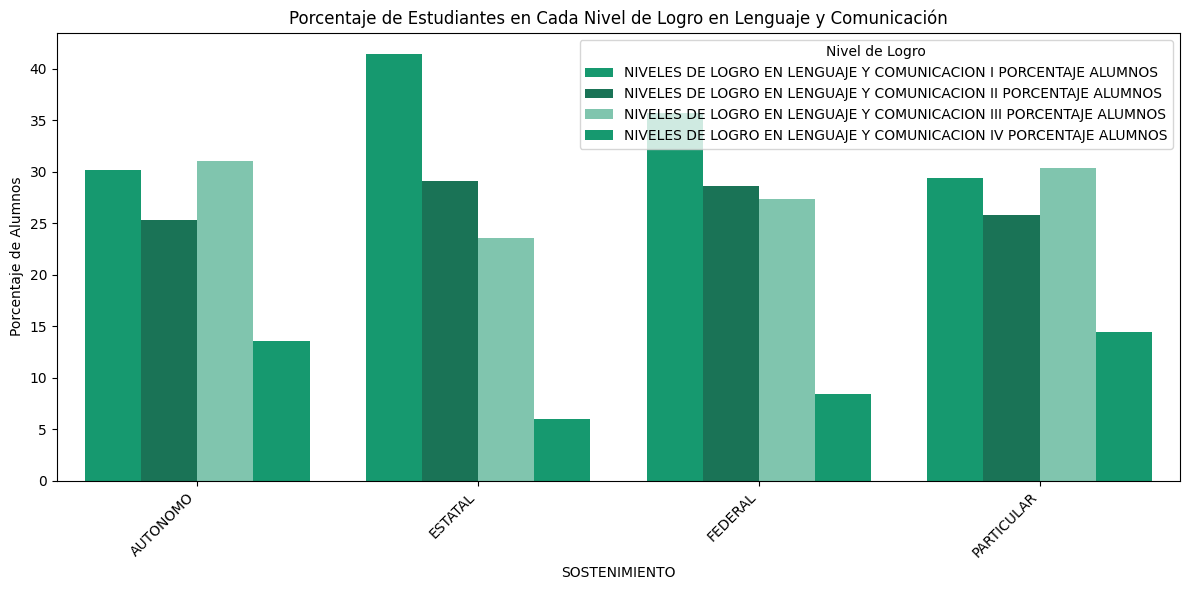

,SOSTENIMIENTO,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,AUTONOMO,58.367096,23.942974,11.791803,5.901054
1,ESTATAL,67.480660,21.828296,7.578577,3.116052
2,FEDERAL,64.761657,22.460557,8.897067,3.882331
3,PARTICULAR,66.043812,20.621156,8.416381,4.920578


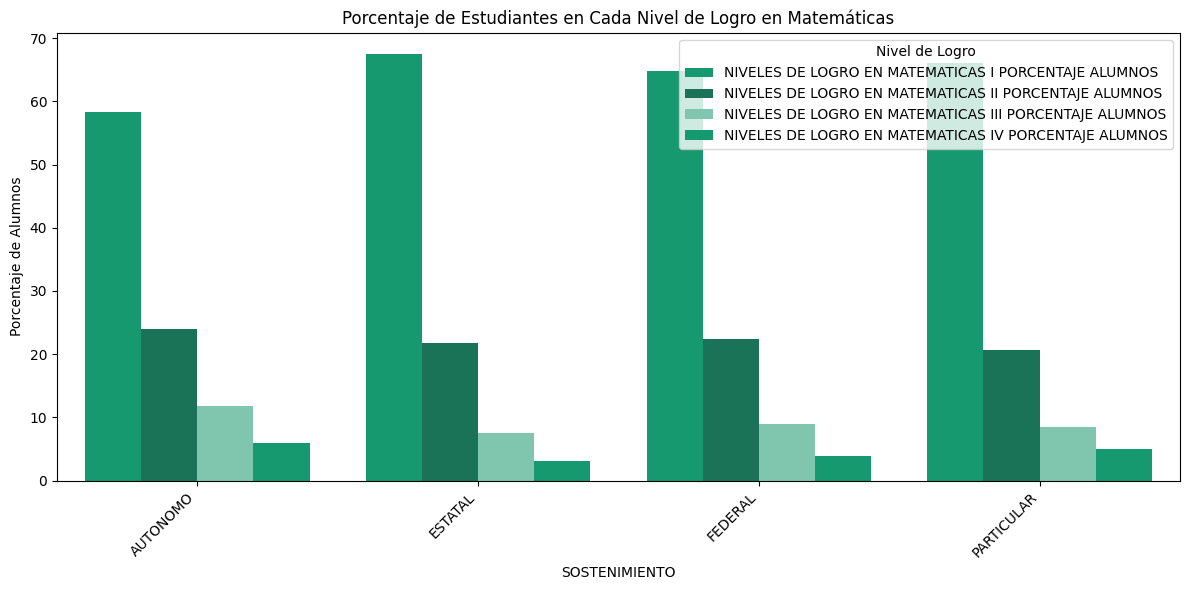

,SUBSISTEMA,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,BACH ESTATAL DGE-CGE,35.409838,30.073094,26.686227,7.831382
1,BACHI AUTONOMO,30.150585,25.329040,30.986885,13.532670
2,CECYTE,36.474336,30.305563,26.450316,6.776233
3,CETI,4.350000,12.100000,42.800000,40.750000
4,COBACH,38.475934,28.404656,25.287738,7.836787
5,COLBACH MEX,14.587500,29.625000,44.492500,11.305000
6,CONALEP DF -OAX,52.198387,29.064516,16.529032,2.208065
7,CONALEP EDOS,39.977169,31.086073,23.717808,5.223288
8,DGB,32.981034,27.375862,29.858621,9.791379
9,DGECYTM,45.686667,27.966667,20.820000,5.530000


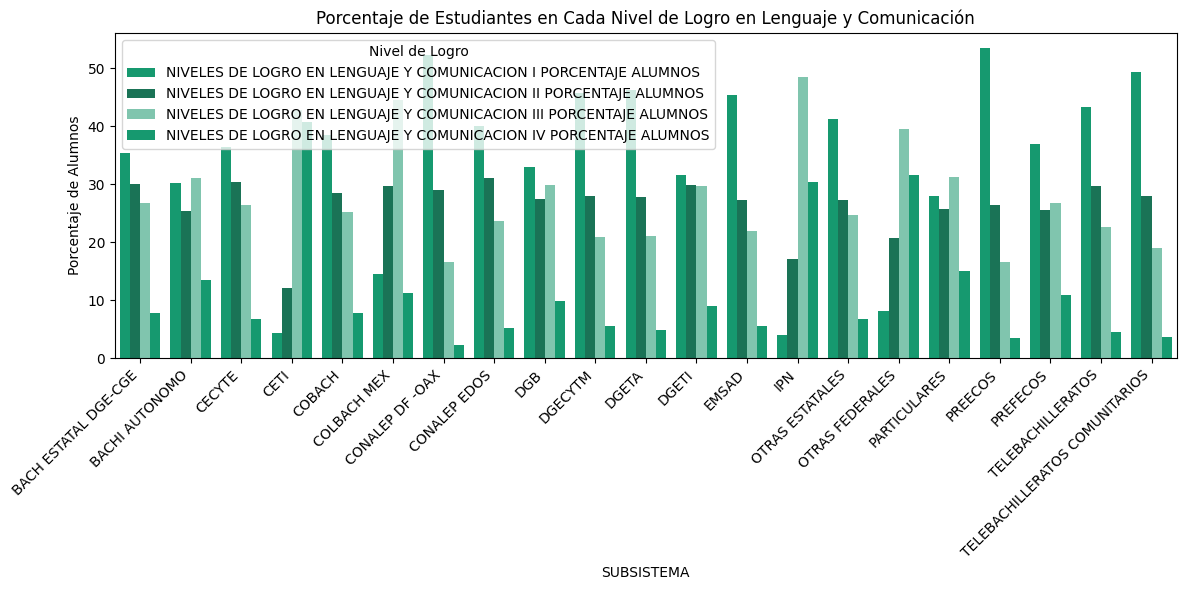

,SUBSISTEMA,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,BACH ESTATAL DGE-CGE,62.535858,24.416085,9.212445,3.838810
1,BACHI AUTONOMO,58.367096,23.942974,11.791803,5.901054
2,CECYTE,63.294311,24.255120,9.090013,3.367636
3,CETI,13.950000,27.300000,33.650000,25.150000
4,COBACH,66.265377,22.234754,7.894361,3.609443
5,COLBACH MEX,71.467500,23.980000,3.867500,0.692500
6,CONALEP DF -OAX,87.996774,10.677419,1.130645,0.193548
7,CONALEP EDOS,67.486073,21.600000,7.391553,3.527169
8,DGB,68.753448,20.341379,8.279310,2.620690
9,DGECYTM,74.926667,17.256667,6.341667,1.483333


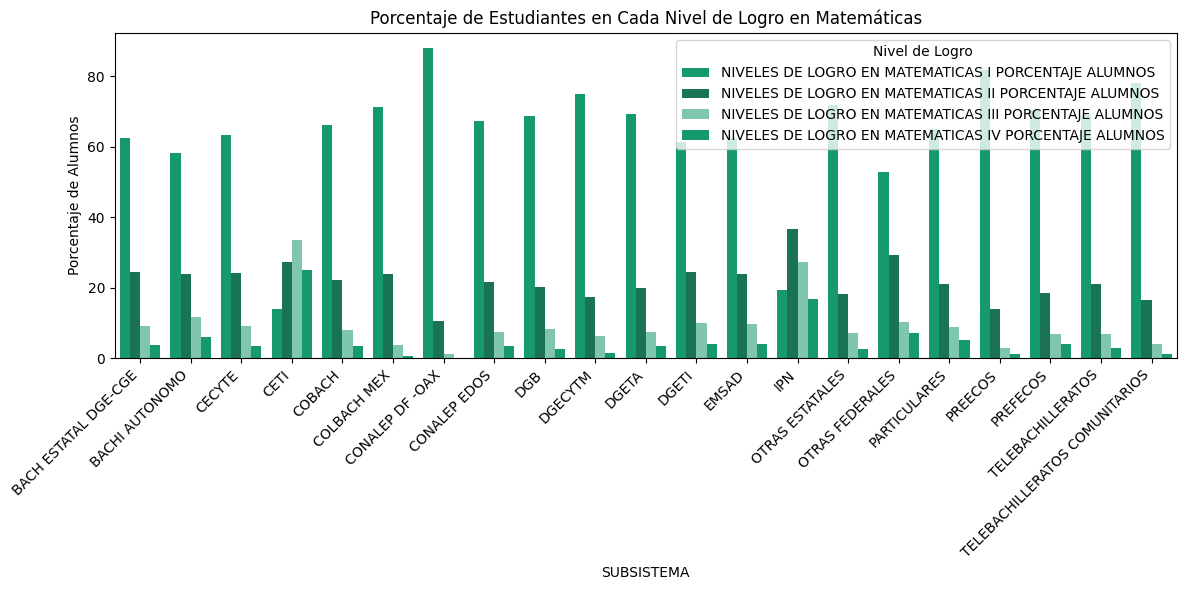

,TURNO,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,DISCONTINUO,16.156000,27.332000,40.442000,16.068000
1,MATUTINO,34.881707,27.558158,27.420550,10.142737
2,NOCTURNO,50.813636,26.494697,18.391667,4.303788
3,VESPERTINO,42.107727,28.850700,23.127926,5.919340


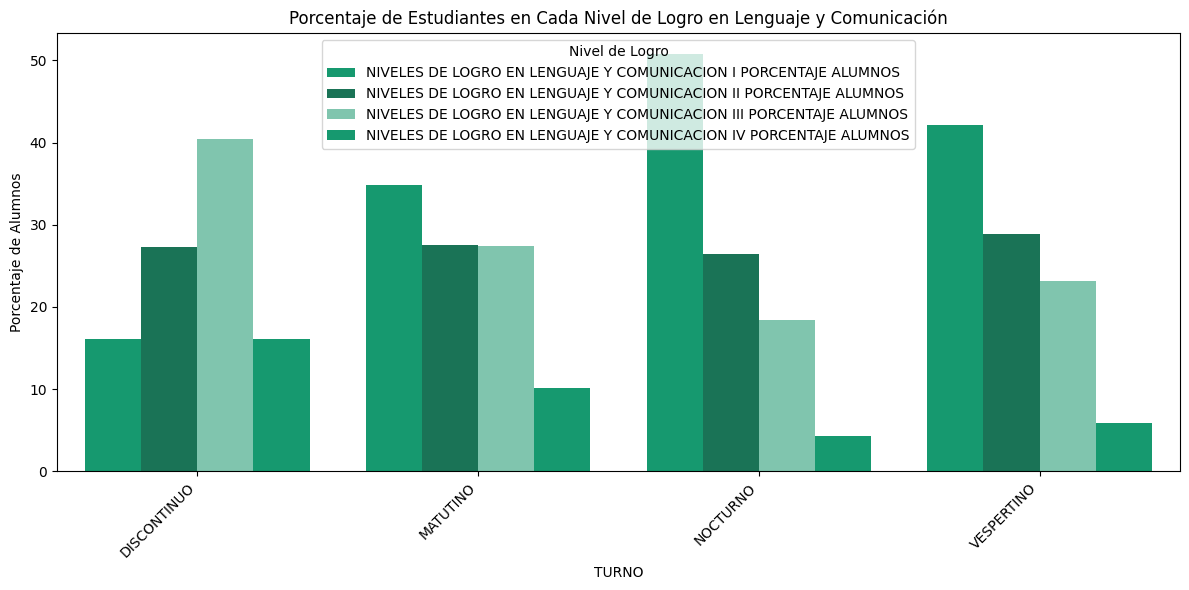

,TURNO,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,DISCONTINUO,58.186000,27.576000,10.374000,3.878000
1,MATUTINO,63.752867,22.828210,9.055772,4.365971
2,NOCTURNO,84.326515,12.918182,1.960606,0.795455
3,VESPERTINO,72.856258,18.706688,5.900542,2.539607


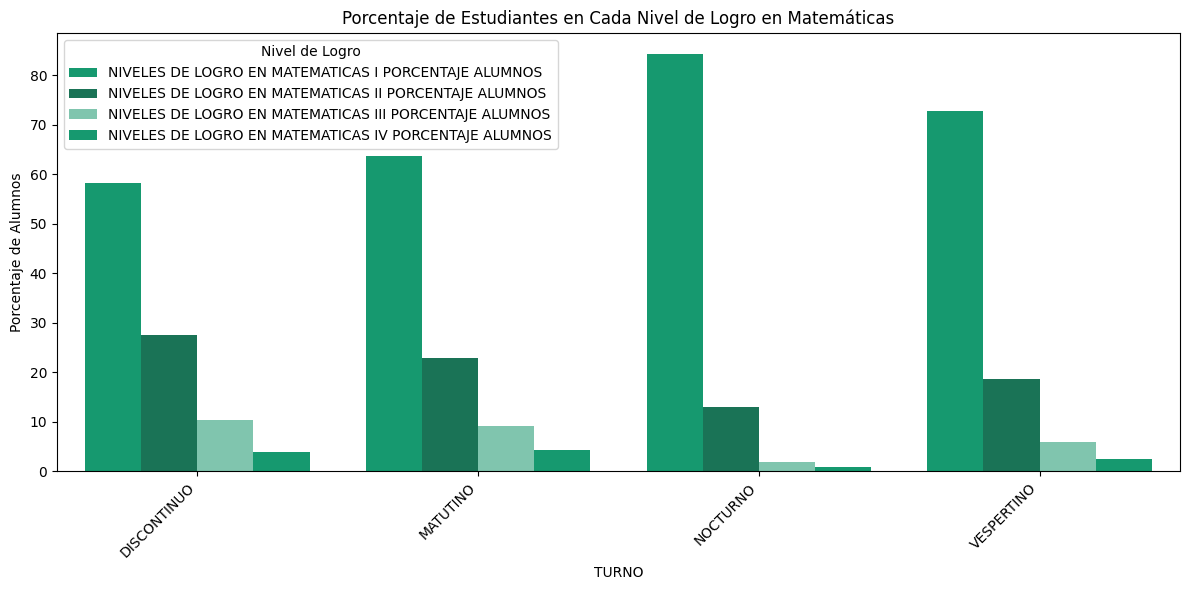

,GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,ALTO,45.912721,28.414220,21.051100,4.627642
1,BAJO,36.387978,28.718272,26.631397,8.265809
2,MEDIO,41.084545,29.335487,23.512924,6.068498
3,MUY ALTO,58.956751,22.843936,15.049886,3.151259
4,MUY BAJO,29.517524,27.229280,30.423152,12.833685


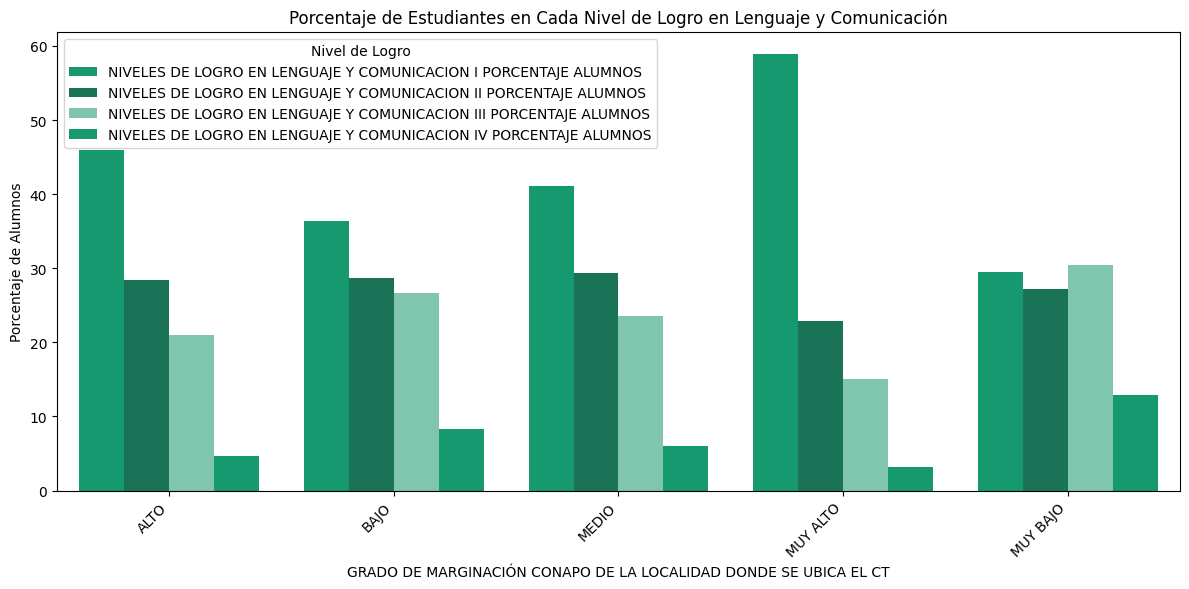

,GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,ALTO,68.807618,20.700967,7.349117,3.146385
1,BAJO,65.645074,22.541029,8.268750,3.547243
2,MEDIO,67.357889,21.630264,7.745288,3.269305
3,MUY ALTO,72.840732,19.124943,6.219908,1.813730
4,MUY BAJO,64.588730,22.009366,8.782685,4.622026


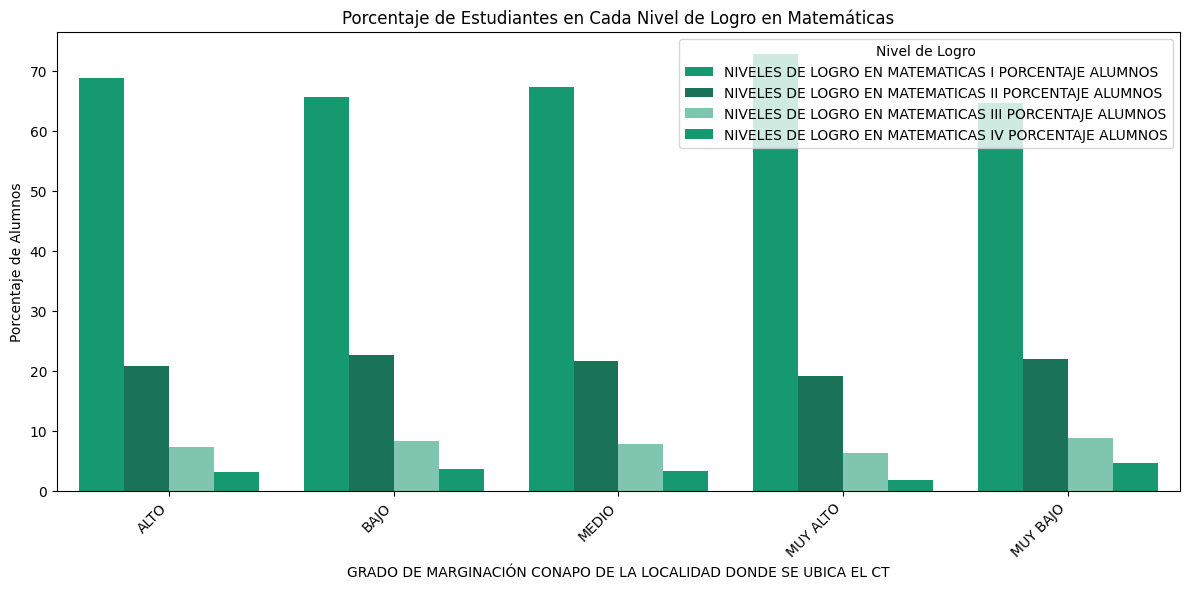

In [59]:


def crear_grafica(df_melted, title, categoria_col):
    """Crea el gráfico de barras con estilo mejorado."""
    plt.figure(figsize=(12, 6))

    # Paleta de colores personalizada basada en #00af77 con tonos más oscuros
    n_colors = len(df_melted["Nivel de Logro"].unique())
    verde_base = "#00af77"
    palette_dark = sns.dark_palette(verde_base, n_colors=n_colors, reverse=True)  # Tonos más oscuros
    palette_light = sns.light_palette(verde_base, n_colors=n_colors // 2 + 1)[1:]  # Tonos más claros, excluyendo el base
    palette = palette_dark[:-len(palette_light)] + palette_light  # Combina y ajusta el orden

    sns.barplot(data=df_melted, x=categoria_col, y="Porcentaje de Alumnos", hue="Nivel de Logro", palette=palette, errorbar=None)

    plt.title(f'Porcentaje de Estudiantes en Cada Nivel de Logro en {title}')
    plt.xlabel(categoria_col)
    plt.ylabel('Porcentaje de Alumnos')
    plt.xticks(rotation=45, ha='right')  # Rotación y alineación de etiquetas
    plt.tight_layout()
    plt.show()

def procesar_y_graficar(df, categorias, nivel_logro_lenguaje, nivel_logro_matematicas):
    """Procesa, muestra y grafica KPIs para múltiples categorías."""
    for categoria in categorias:
        # Lenguaje
        df_lenguaje = calcular_kpis_por_categoria(df, [categoria], nivel_logro_lenguaje)
        df_lenguaje_melted = df_lenguaje.melt(id_vars=categoria, value_vars=nivel_logro_lenguaje, var_name="Nivel de Logro", value_name="Porcentaje de Alumnos")
        display(df_lenguaje)
        crear_grafica(df_lenguaje_melted, "Lenguaje y Comunicación", categoria)

        # Matemáticas
        df_matematicas = calcular_kpis_por_categoria(df, [categoria], nivel_logro_matematicas)
        df_matematicas_melted = df_matematicas.melt(id_vars=categoria, value_vars=nivel_logro_matematicas, var_name="Nivel de Logro", value_name="Porcentaje de Alumnos")
        display(df_matematicas)
        crear_grafica(df_matematicas_melted, "Matemáticas", categoria)

# Lista de categorías
categorias = ["SOSTENIMIENTO", "SUBSISTEMA", "TURNO", "GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT"]

# Llamada a la función principal
procesar_y_graficar(df, categorias, nivel_logro_lenguaje, nivel_logro_matematicas)

### A nivel entidad federativa

• Lenguaje y comunicación

o Porcentaje de estudiantes en cada nivel de logro por estado.

o Porcentaje de estudiantes en cada nivel de logro por tipo de
sostenimiento.

o Porcentaje de estudiantes en cada nivel de logro por subsistema.

o Porcentaje de estudiantes en cada nivel de logro por turno.

o Porcentaje de estudiantes en cada nivel de logro grado marginación.



• Matemáticas

o Porcentaje de estudiantes en cada nivel de logro.

o Porcentaje de estudiantes en cada nivel de logro por tipo de
sostenimiento.

o Porcentaje de estudiantes en cada nivel de logro por subsistema.

o Porcentaje de estudiantes en cada nivel de logro por turno.

o Porcentaje de estudiantes en cada nivel de logro grado marginación.


,ENTIDAD,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,33.318692,28.765421,27.918224,10.003271
1,BAJA CALIFORNIA,31.708815,29.398072,28.199174,10.698347
2,BAJA CALIFORNIA SUR,31.853211,27.027523,28.327523,12.786239
3,CAMPECHE,33.268657,30.400746,27.348507,8.984328
4,CHIAPAS,56.677793,23.833647,15.852355,3.637954
5,CHIHUAHUA,42.697904,26.641090,23.306080,7.360587
6,CIUDAD DE MEXICO,27.723515,26.958195,32.267458,13.055107
7,COAHUILA,39.401235,25.551235,25.511111,9.540741
8,COLIMA,33.072414,26.728448,28.713793,11.491379
9,DURANGO,40.309091,25.189161,26.413986,8.092657


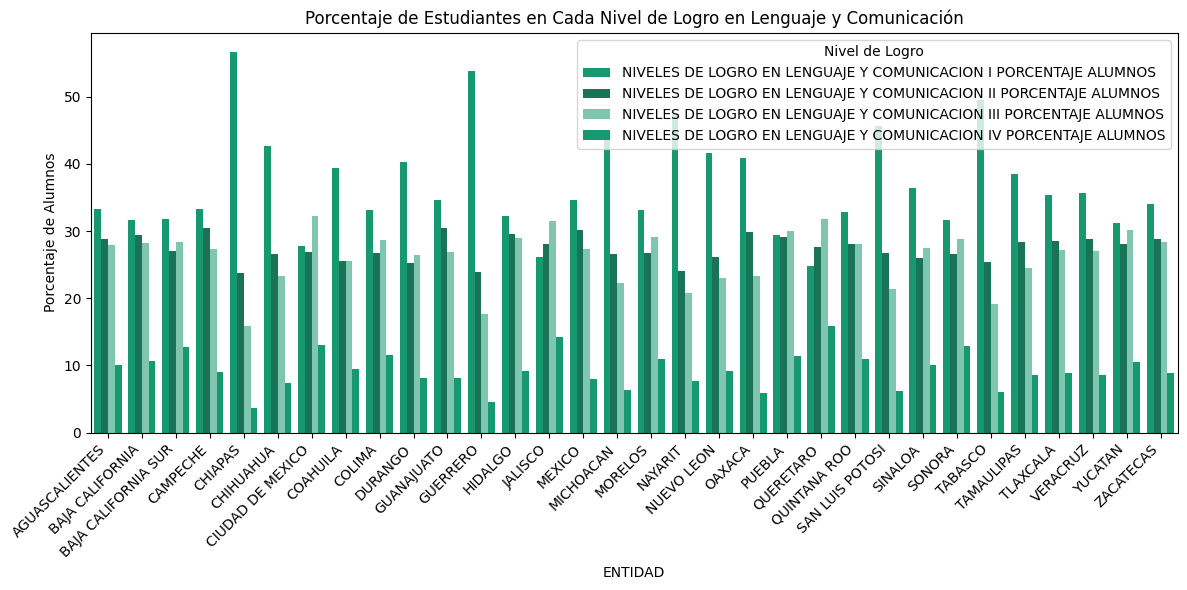

,ENTIDAD,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,68.009346,20.591121,7.939720,3.465888
1,BAJA CALIFORNIA,68.896419,20.083196,7.239394,3.781267
2,BAJA CALIFORNIA SUR,65.176147,20.255046,9.546789,5.021101
3,CAMPECHE,68.737313,21.383582,6.798507,3.078358
4,CHIAPAS,69.444953,19.231359,8.054105,3.272140
5,CHIHUAHUA,71.297694,19.057862,6.696436,2.951992
6,CIUDAD DE MEXICO,68.916390,20.448694,7.071021,3.561283
7,COAHUILA,69.686214,19.085802,7.173663,4.056996
8,COLIMA,67.509483,20.504310,7.484483,4.500862
9,DURANGO,64.853497,22.058042,9.030070,4.063287


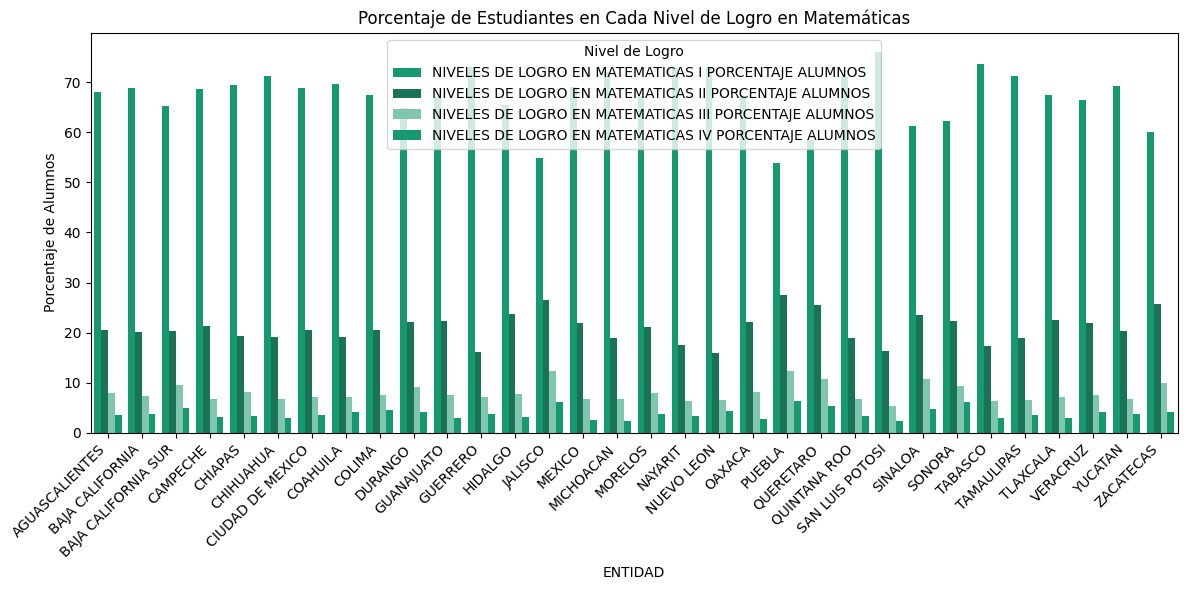

,ENTIDAD,SOSTENIMIENTO,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,AUTONOMO,2.600000,10.350000,43.825000,43.250000
1,AGUASCALIENTES,ESTATAL,41.894898,29.060204,23.600000,5.455102
2,AGUASCALIENTES,FEDERAL,25.767647,30.835294,31.458824,11.941176
3,AGUASCALIENTES,PARTICULAR,27.410256,28.437179,30.984615,13.167949
4,BAJA CALIFORNIA,ESTATAL,33.334868,30.803289,28.053947,7.815789
...,...,...,...,...,...,...
112,YUCATAN,PARTICULAR,19.446939,23.218367,36.805102,20.539796
113,ZACATECAS,AUTONOMO,28.805882,28.152941,33.105882,9.952941
114,ZACATECAS,ESTATAL,36.220000,30.722632,26.174737,6.890526
115,ZACATECAS,FEDERAL,29.973913,27.691304,31.256522,11.086957


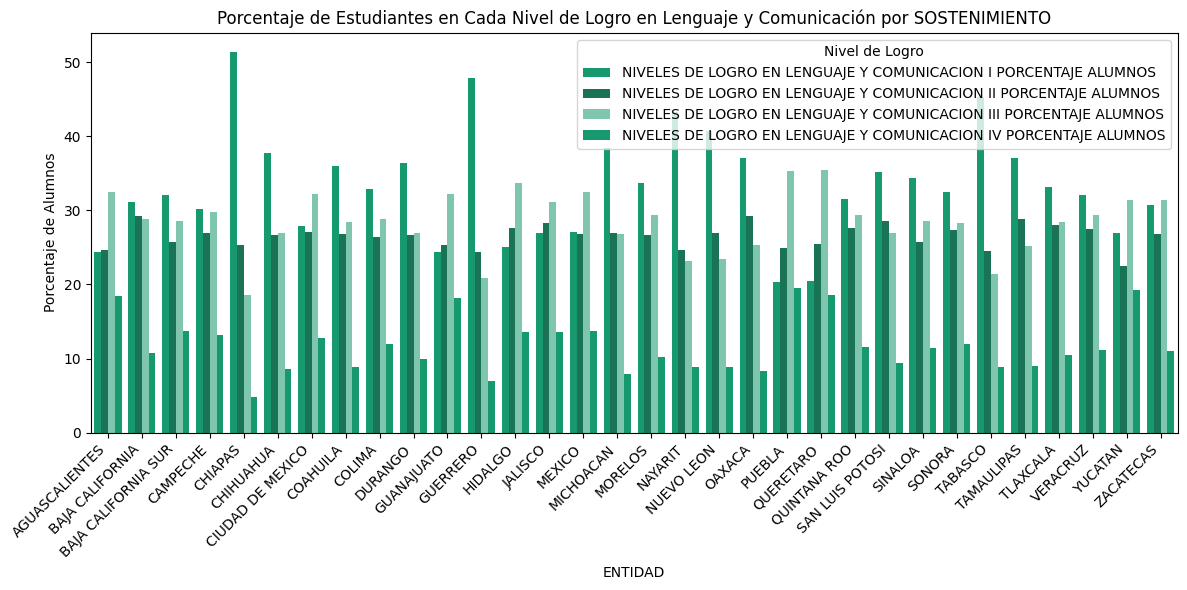

,ENTIDAD,SOSTENIMIENTO,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,AUTONOMO,25.075000,32.975000,25.450000,16.525000
1,AGUASCALIENTES,ESTATAL,72.233673,20.237755,6.015306,1.526531
2,AGUASCALIENTES,FEDERAL,58.647059,25.344118,12.055882,3.944118
3,AGUASCALIENTES,PARTICULAR,68.984615,18.328205,7.665385,5.024359
4,BAJA CALIFORNIA,ESTATAL,67.655921,23.103947,6.623684,2.615789
...,...,...,...,...,...,...
112,YUCATAN,PARTICULAR,59.574490,23.878571,9.875510,6.676531
113,ZACATECAS,AUTONOMO,65.852941,22.064706,9.200000,2.876471
114,ZACATECAS,ESTATAL,60.652632,26.208947,9.995789,3.144737
115,ZACATECAS,FEDERAL,55.178261,24.769565,11.326087,8.726087


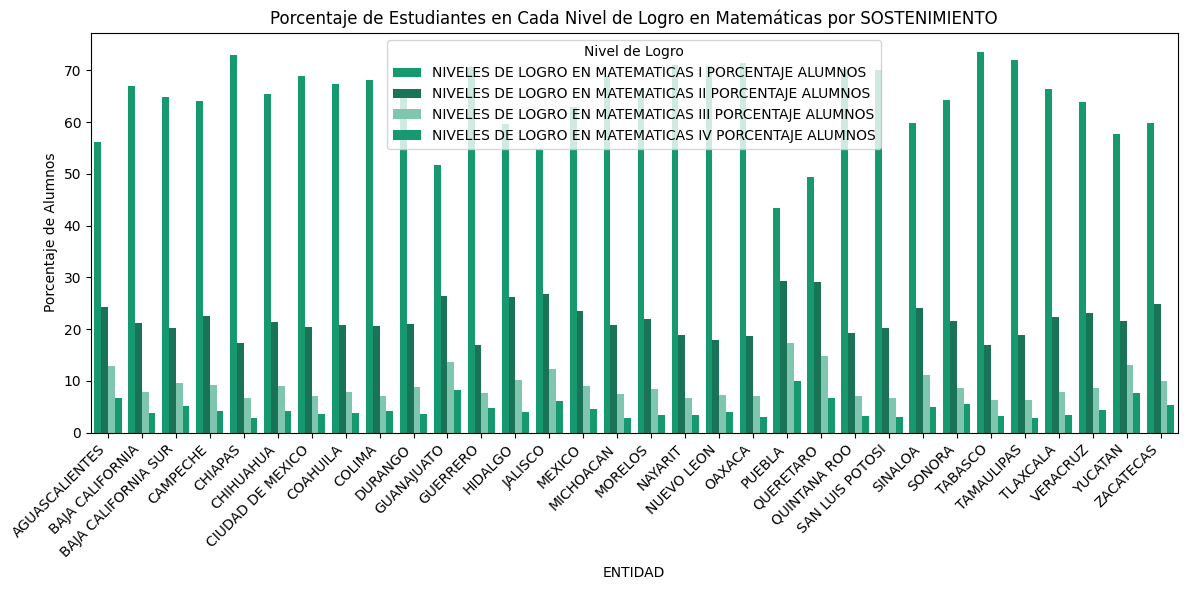

,ENTIDAD,SUBSISTEMA,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,BACH ESTATAL DGE-CGE,8.650000,20.700000,50.000000,20.675000
1,AGUASCALIENTES,BACHI AUTONOMO,2.600000,10.350000,43.825000,43.250000
2,AGUASCALIENTES,CECYTE,36.873684,32.826316,25.452632,4.831579
3,AGUASCALIENTES,CONALEP EDOS,27.900000,29.222222,35.200000,7.700000
4,AGUASCALIENTES,DGB,22.833333,30.616667,31.433333,15.116667
...,...,...,...,...,...,...
397,ZACATECAS,DGETI,31.740000,29.770000,29.830000,8.650000
398,ZACATECAS,EMSAD,30.097619,29.657143,30.569048,9.676190
399,ZACATECAS,IPN,1.600000,9.400000,53.100000,35.900000
400,ZACATECAS,PARTICULARES,28.085000,20.605000,34.970000,16.342500


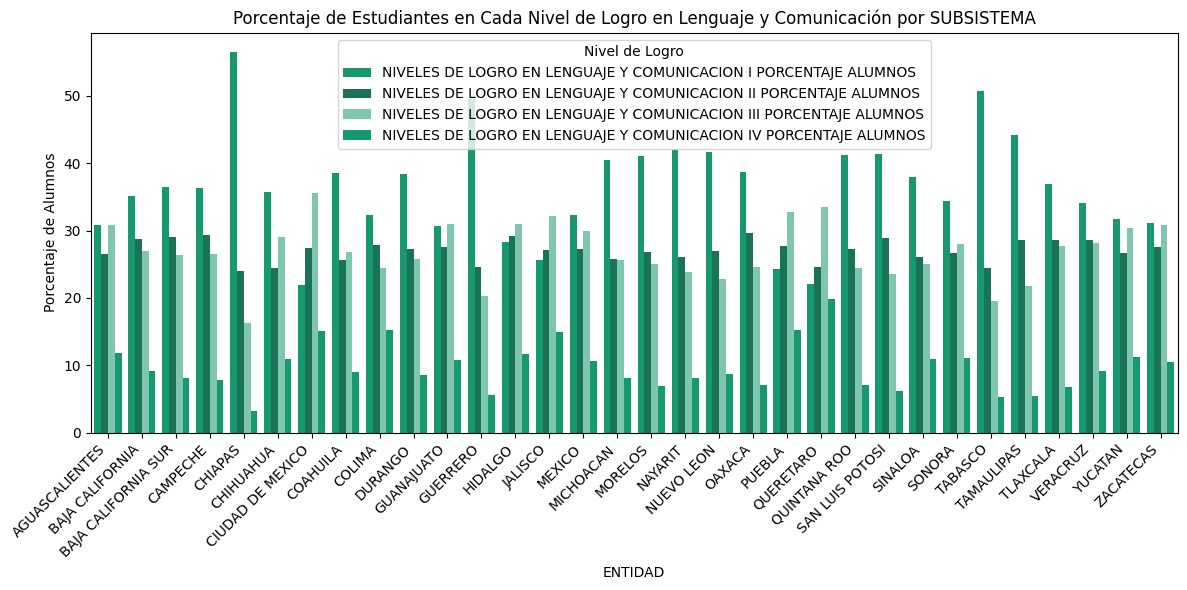

,ENTIDAD,SUBSISTEMA,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,BACH ESTATAL DGE-CGE,74.525000,17.625000,7.500000,0.375000
1,AGUASCALIENTES,BACHI AUTONOMO,25.075000,32.975000,25.450000,16.525000
2,AGUASCALIENTES,CECYTE,68.621053,24.252632,5.410526,1.742105
3,AGUASCALIENTES,CONALEP EDOS,59.677778,24.822222,12.377778,3.144444
4,AGUASCALIENTES,DGB,62.450000,24.650000,10.833333,2.066667
...,...,...,...,...,...,...
397,ZACATECAS,DGETI,61.990000,24.030000,10.080000,3.900000
398,ZACATECAS,EMSAD,41.050000,37.030952,15.907143,6.011905
399,ZACATECAS,IPN,18.500000,30.800000,24.600000,26.200000
400,ZACATECAS,PARTICULARES,57.892500,26.055000,9.690000,6.367500


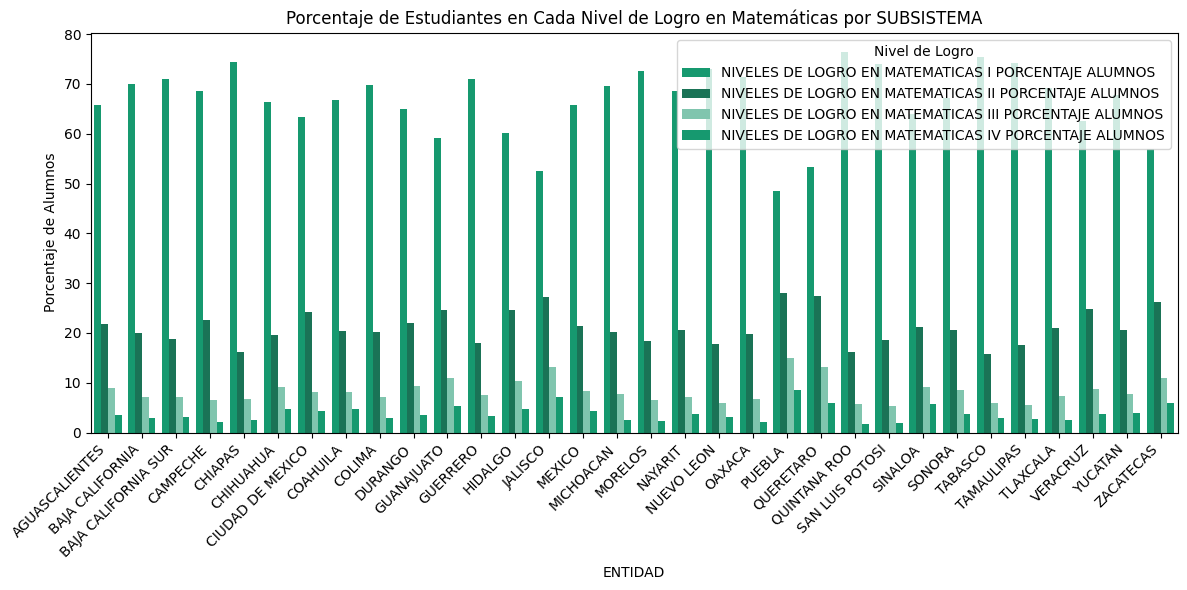

,ENTIDAD,TURNO,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,MATUTINO,28.123387,28.087903,30.632258,13.154839
1,AGUASCALIENTES,NOCTURNO,46.400000,35.700000,14.300000,3.600000
2,AGUASCALIENTES,VESPERTINO,40.410112,29.631461,24.289888,5.684270
3,BAJA CALIFORNIA,MATUTINO,28.705350,28.119342,29.714403,13.465432
4,BAJA CALIFORNIA,NOCTURNO,38.375000,35.225000,22.875000,3.525000
...,...,...,...,...,...,...
86,YUCATAN,MATUTINO,26.325381,27.160914,32.502538,14.019797
87,YUCATAN,NOCTURNO,35.850000,19.425000,41.925000,2.775000
88,YUCATAN,VESPERTINO,37.590667,29.526667,26.611333,6.269333
89,ZACATECAS,MATUTINO,31.710132,28.599559,29.967401,9.727753


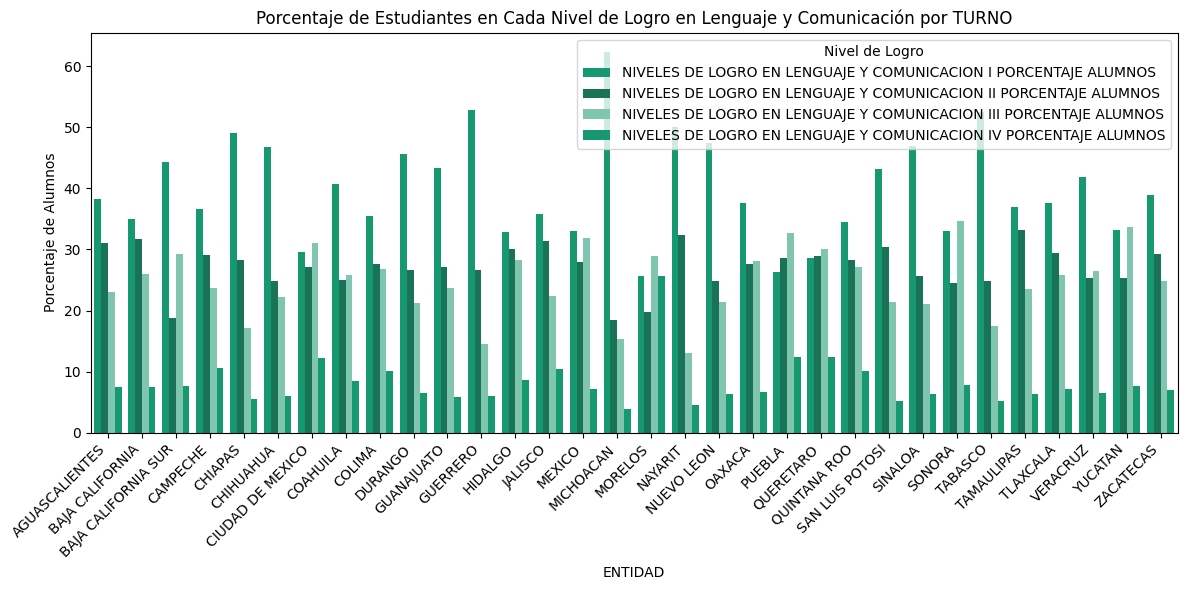

,ENTIDAD,TURNO,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,MATUTINO,63.708065,22.004839,9.368548,4.926613
1,AGUASCALIENTES,NOCTURNO,96.600000,3.400000,0.000000,0.000000
2,AGUASCALIENTES,VESPERTINO,73.680899,18.814607,6.038202,1.469663
3,BAJA CALIFORNIA,MATUTINO,65.186420,21.293827,8.650617,4.870370
4,BAJA CALIFORNIA,NOCTURNO,89.050000,10.950000,0.000000,0.000000
...,...,...,...,...,...,...
86,YUCATAN,MATUTINO,63.143655,23.550254,8.353807,4.958376
87,YUCATAN,NOCTURNO,94.450000,3.325000,0.550000,1.675000
88,YUCATAN,VESPERTINO,76.826000,16.426667,4.774000,1.978667
89,ZACATECAS,MATUTINO,56.417181,27.618502,11.149780,4.816300


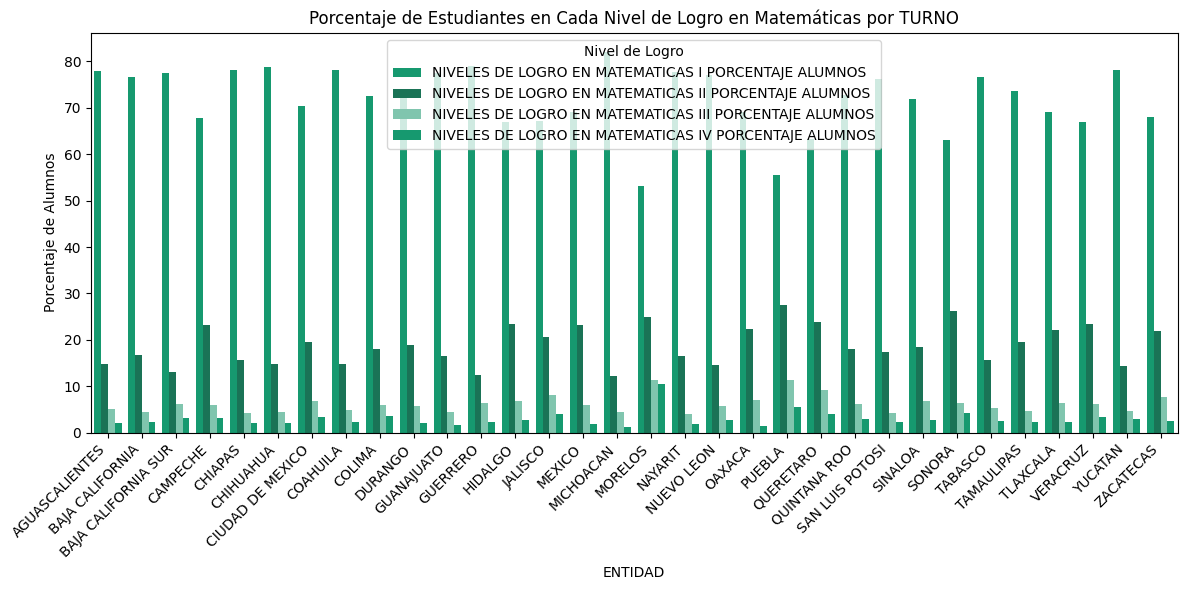

,ENTIDAD,GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,ALTO,53.811111,30.488889,12.533333,3.188889
1,AGUASCALIENTES,BAJO,37.194872,28.951282,24.815385,9.030769
2,AGUASCALIENTES,MEDIO,52.665000,27.765000,17.085000,2.505000
3,AGUASCALIENTES,MUY BAJO,28.369863,28.746575,31.179452,11.710274
4,BAJA CALIFORNIA,ALTO,49.888889,22.600000,22.288889,5.211111
...,...,...,...,...,...,...
142,ZACATECAS,ALTO,46.244000,27.880000,20.792000,5.100000
143,ZACATECAS,BAJO,36.250000,30.379268,27.089024,6.290244
144,ZACATECAS,MEDIO,37.585455,30.794545,24.063636,7.561818
145,ZACATECAS,MUY ALTO,50.000000,46.200000,3.800000,0.000000


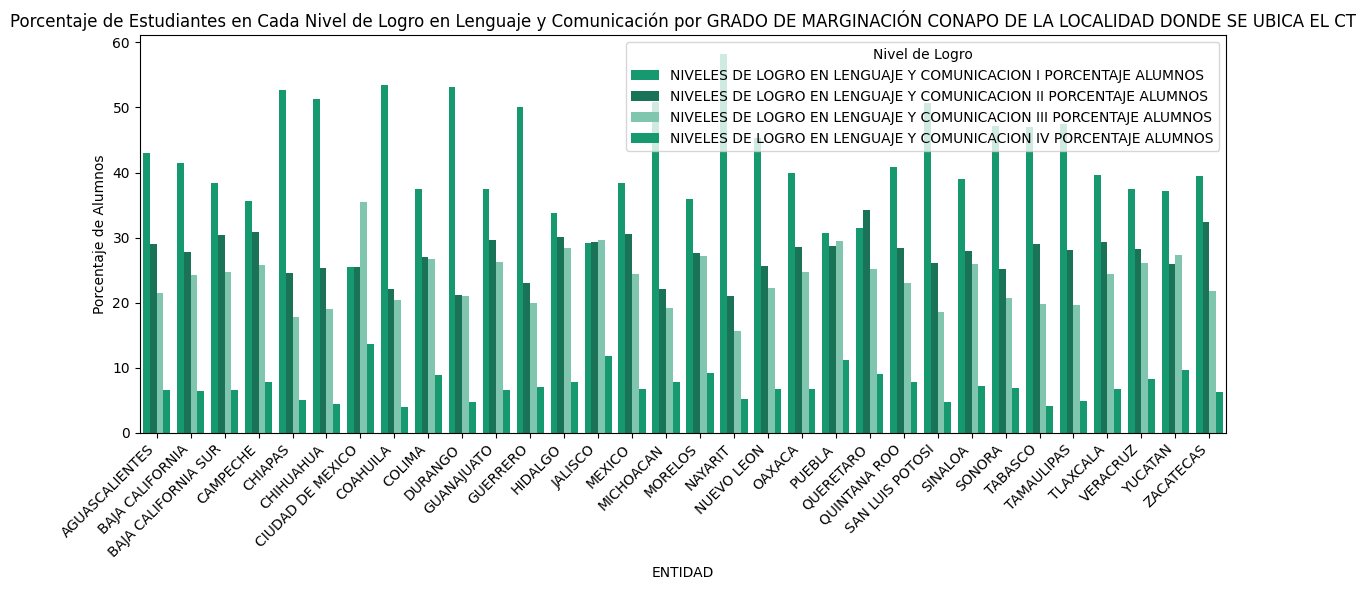

,ENTIDAD,GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT,NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS,NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
0,AGUASCALIENTES,ALTO,78.444444,16.677778,4.400000,0.477778
1,AGUASCALIENTES,BAJO,65.310256,23.707692,8.010256,2.987179
2,AGUASCALIENTES,MEDIO,81.930000,13.910000,3.180000,0.975000
3,AGUASCALIENTES,MUY BAJO,66.180137,20.915068,8.791096,4.119178
4,BAJA CALIFORNIA,ALTO,71.622222,25.555556,2.833333,0.000000
...,...,...,...,...,...,...
142,ZACATECAS,ALTO,71.384000,20.872000,6.484000,1.260000
143,ZACATECAS,BAJO,57.440244,28.903659,10.196341,3.462195
144,ZACATECAS,MEDIO,63.514545,22.885455,9.898182,3.710909
145,ZACATECAS,MUY ALTO,50.000000,46.200000,3.800000,0.000000


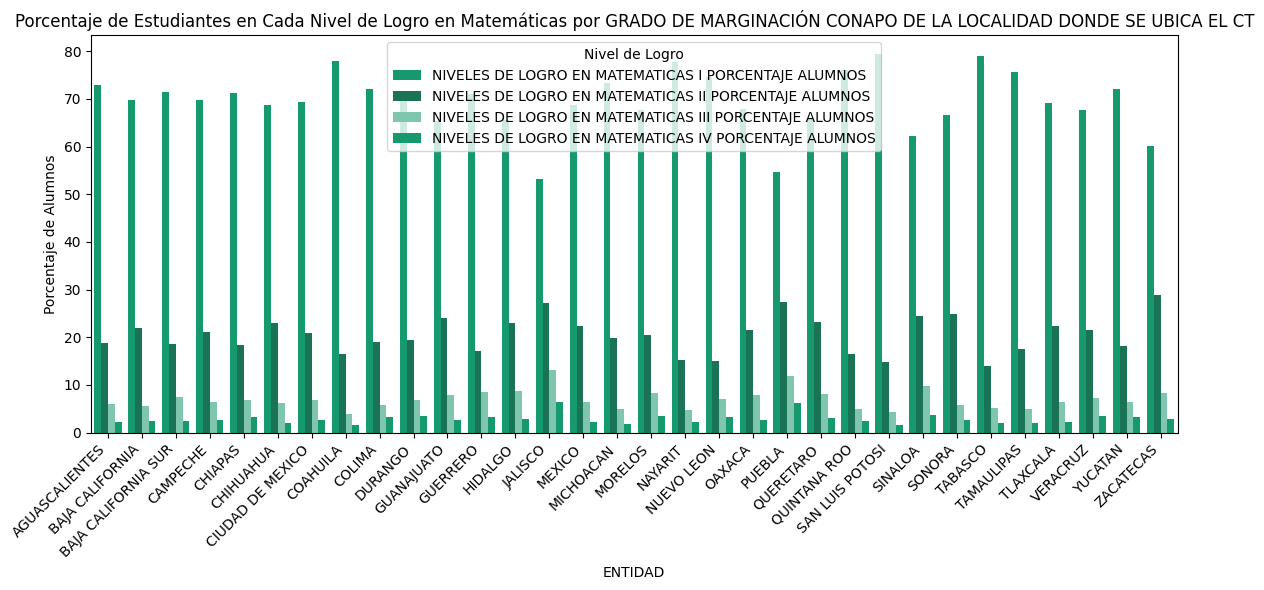

In [60]:

# (Tus funciones calcular_kpis_por_categoria y crear_grafica aquí)

def mostrar_tabla(df):
    """Muestra un DataFrame."""
    display(df)

def procesar_y_graficar_entidad(df, nivel_logro_lenguaje, nivel_logro_matematicas):
    """Procesa y grafica KPIs por entidad."""
    # KPIs por entidad
    df_lenguaje_entidad = calcular_kpis_por_categoria(df, ["ENTIDAD"], nivel_logro_lenguaje)
    df_matematicas_entidad = calcular_kpis_por_categoria(df, ["ENTIDAD"], nivel_logro_matematicas)

    # Transformación y gráficos
    df_lenguaje_entidad_melted = df_lenguaje_entidad.melt(id_vars="ENTIDAD", value_vars=nivel_logro_lenguaje, var_name="Nivel de Logro", value_name="Porcentaje de Alumnos")
    df_matematicas_entidad_melted = df_matematicas_entidad.melt(id_vars="ENTIDAD", value_vars=nivel_logro_matematicas, var_name="Nivel de Logro", value_name="Porcentaje de Alumnos")

    mostrar_tabla(df_lenguaje_entidad)
    crear_grafica(df_lenguaje_entidad_melted, "Lenguaje y Comunicación", "ENTIDAD")
    mostrar_tabla(df_matematicas_entidad)
    crear_grafica(df_matematicas_entidad_melted, "Matemáticas", "ENTIDAD")

def procesar_y_graficar_entidad_categorias(df, categorias_adicionales, nivel_logro_lenguaje, nivel_logro_matematicas):
    """Procesa y grafica KPIs por entidad y categorías adicionales."""
    for categoria in categorias_adicionales:
        # KPIs por entidad y categoría
        df_lenguaje = calcular_kpis_por_categoria(df, ["ENTIDAD", categoria], nivel_logro_lenguaje)
        df_matematicas = calcular_kpis_por_categoria(df, ["ENTIDAD", categoria], nivel_logro_matematicas)

        # Transformación y gráficos
        df_lenguaje_melted = df_lenguaje.melt(id_vars=["ENTIDAD", categoria], value_vars=nivel_logro_lenguaje, var_name="Nivel de Logro", value_name="Porcentaje de Alumnos")
        df_matematicas_melted = df_matematicas.melt(id_vars=["ENTIDAD", categoria], value_vars=nivel_logro_matematicas, var_name="Nivel de Logro", value_name="Porcentaje de Alumnos")

        mostrar_tabla(df_lenguaje)
        crear_grafica(df_lenguaje_melted, f"Lenguaje y Comunicación por {categoria}", "ENTIDAD")
        mostrar_tabla(df_matematicas)
        crear_grafica(df_matematicas_melted, f"Matemáticas por {categoria}", "ENTIDAD")

# Lista de categorías adicionales
categorias_adicionales = ["SOSTENIMIENTO", "SUBSISTEMA", "TURNO", "GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT"]

# Llamadas a las funciones principales
procesar_y_graficar_entidad(df, nivel_logro_lenguaje, nivel_logro_matematicas)
procesar_y_graficar_entidad_categorias(df, categorias_adicionales, nivel_logro_lenguaje, nivel_logro_matematicas)

In [61]:
# Suponiendo que ya tienes un DataFrame df con una columna 'CLAVE DE LA ESCUELA'

# Definir la función para calcular el total de escuelas únicas
def calcular_total_escuelas(df):
    # Contamos el número de claves de escuela únicas
    total_escuelas = df["CLAVE DE LA ESCUELA"].nunique()
    return total_escuelas

# Calcular el total de escuelas evaluadas
total_escuelas = calcular_total_escuelas(df)

# Imprimir el total de escuelas en Jupyter
total_escuelas


14634

c) Chunk de 5 entidades con el mayor porcentaje de estudiantes con nivel 4 de Matemáticas, ordenados de manera descendente

Top 5 entidades con mayor porcentaje de estudiantes en el nivel 4 de Matemáticas:
                ENTIDAD  NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
20               PUEBLA                                           6.274336    
25               SONORA                                           6.157099    
13              JALISCO                                           6.146944    
21            QUERETARO                                           5.247104    
2   BAJA CALIFORNIA SUR                                           5.021101    


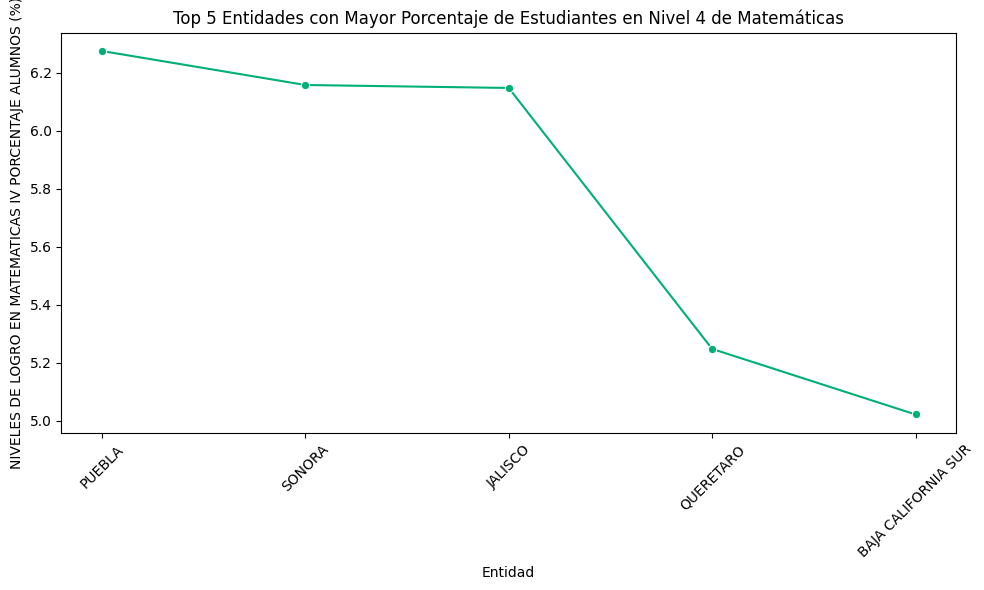

In [62]:

def crear_grafica(df_melted, title, categoria_col):
    """Crea el gráfico de barras con estilo mejorado."""
    plt.figure(figsize=(12, 6))

    # Paleta de colores personalizada basada en #00af77 con tonos más oscuros y claros combinados
    n_colors = len(df_melted["Nivel de Logro"].unique())
    verde_base = "#00af77"
    palette_dark = sns.dark_palette(verde_base, n_colors=n_colors, reverse=True)  # Tonos más oscuros
    palette_light = sns.light_palette(verde_base, n_colors=n_colors // 2 + 1)[1:]  # Tonos más claros, excluyendo el base
    palette = palette_dark[:-len(palette_light)] + palette_light  # Combina y ajusta el orden

    sns.barplot(data=df_melted, x=categoria_col, y="Porcentaje de Alumnos", hue="Nivel de Logro", palette=palette, errorbar=None)

    plt.title(f'Porcentaje de Estudiantes en Cada Nivel de Logro en {title}')
    plt.xlabel(categoria_col)
    plt.ylabel('Porcentaje de Alumnos')
    plt.xticks(rotation=45, ha='right')  # Rotación y alineación de etiquetas
    plt.tight_layout()
    plt.show()

def top_5_entidades_nivel_4_matematicas(df, nivel_4_matematicas):
    """Calcula y muestra el top 5 de entidades con mayor porcentaje en nivel 4 de Matemáticas."""

    # Crear un DataFrame solo con la entidad y el porcentaje de alumnos en nivel 4 de Matemáticas
    top_entidades_matematicas = df[['ENTIDAD', nivel_4_matematicas]]

    # Agrupar por "ENTIDAD" y calcular el promedio de porcentaje de estudiantes en nivel 4
    top_entidades_matematicas_avg = top_entidades_matematicas.groupby('ENTIDAD')[nivel_4_matematicas].mean().reset_index()

    # Ordenar de manera descendente según el porcentaje de alumnos en nivel 4 de Matemáticas
    top_entidades_matematicas_sorted = top_entidades_matematicas_avg.sort_values(by=nivel_4_matematicas, ascending=False)

    # Obtener el top 5 de entidades
    top_5_entidades_matematicas = top_entidades_matematicas_sorted.head(5)

    # Imprimir la tabla con el top 5 de entidades
    print("Top 5 entidades con mayor porcentaje de estudiantes en el nivel 4 de Matemáticas:")
    print(top_5_entidades_matematicas)

    # Graficar el top 5 de entidades con el mayor porcentaje en el nivel 4 de Matemáticas (Gráfico de Líneas)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=top_5_entidades_matematicas, x='ENTIDAD', y=nivel_4_matematicas, marker='o', color="#00af77")  # Gráfico de líneas con marcadores
    plt.title('Top 5 Entidades con Mayor Porcentaje de Estudiantes en Nivel 4 de Matemáticas')
    plt.xlabel('Entidad')
    plt.ylabel(f'{nivel_4_matematicas} (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Llamada a la función principal
nivel_4_matematicas = "NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS"
top_5_entidades_nivel_4_matematicas(df, nivel_4_matematicas)

Porcentaje de estudiantes evaluados en el nivel 4 de Matemáticas por entidad:

Porcentaje de estudiantes evaluados en el nivel 4 de Matemáticas por entidad:
                ENTIDAD  NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS
20               PUEBLA                                           6.274336    
25               SONORA                                           6.157099    
13              JALISCO                                           6.146944    
21            QUERETARO                                           5.247104    
2   BAJA CALIFORNIA SUR                                           5.021101    
24              SINALOA                                           4.640845    
8                COLIMA                                           4.500862    
18           NUEVO LEON                                           4.341622    
31            ZACATECAS                                           4.080741    
9               DURANGO                                           4.063287    
7              COAHUILA                              

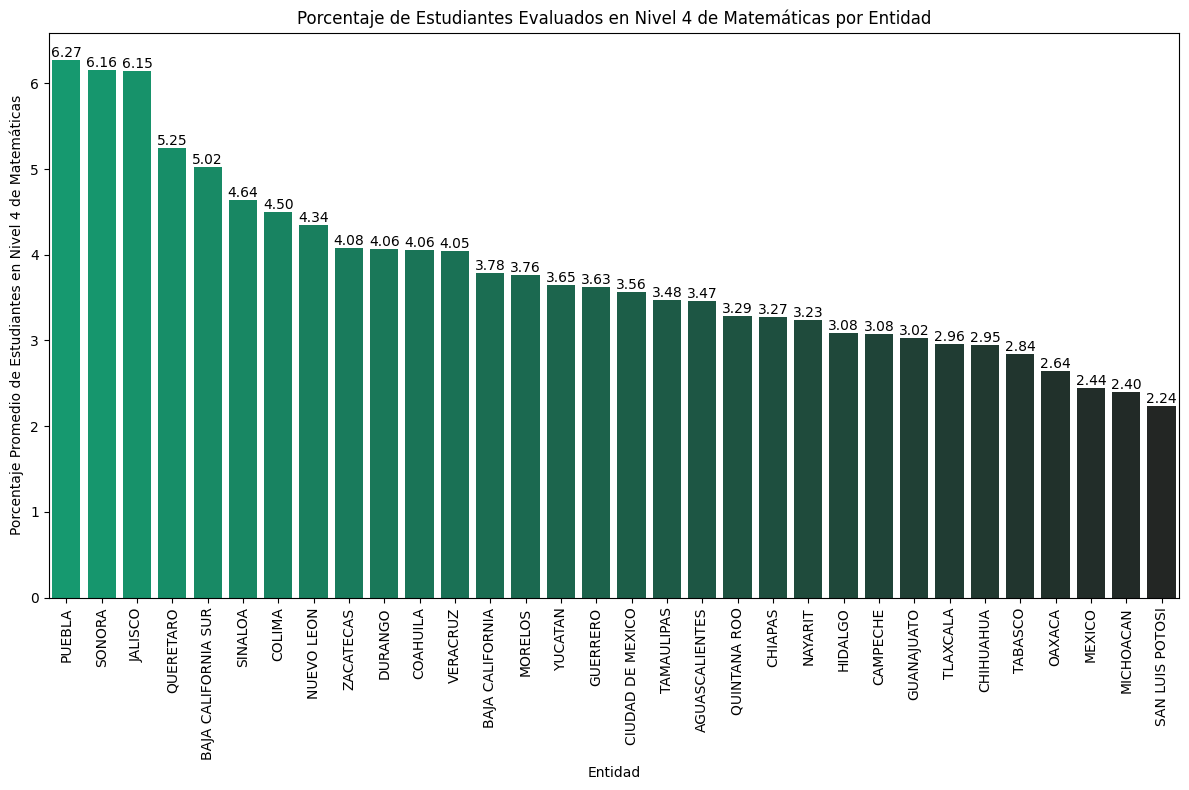

In [63]:


def crear_grafica(df_melted, title, categoria_col):
    """Crea el gráfico de barras con estilo mejorado."""
    plt.figure(figsize=(12, 6))

    # Paleta de colores personalizada basada en #00af77 con tonos más oscuros
    n_colors = len(df_melted["Nivel de Logro"].unique())
    verde_base = "#00af77"
    palette = sns.dark_palette(verde_base, n_colors=n_colors, reverse=True)

    sns.barplot(data=df_melted, x=categoria_col, y="Porcentaje de Alumnos", hue="Nivel de Logro", palette=palette, errorbar=None)

    plt.title(f'Porcentaje de Estudiantes en Cada Nivel de Logro en {title}')
    plt.xlabel(categoria_col)
    plt.ylabel('Porcentaje de Alumnos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Asumo que 'df' es tu DataFrame original

# TODAS LAS ENTIDADES

# Filtrar las columnas necesarias: "Entidad" y "Porcentaje de alumnos evaluados en Matemáticas nivel IV"
nivel_4_matematicas = "NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS"

# Crear un DataFrame solo con la entidad y el porcentaje de alumnos en nivel 4 de Matemáticas
entidades_matematicas = df[['ENTIDAD', nivel_4_matematicas]]

# Agrupar por "ENTIDAD" y calcular el promedio de porcentaje de estudiantes en nivel 4
entidades_matematicas_avg = entidades_matematicas.groupby('ENTIDAD')[nivel_4_matematicas].mean().reset_index()

# Ordenar de manera descendente según el porcentaje de alumnos en nivel 4 de Matemáticas
entidades_matematicas_sorted = entidades_matematicas_avg.sort_values(by=nivel_4_matematicas, ascending=False)

# Imprimir la tabla con los datos completos (todas las entidades)
print("Porcentaje de estudiantes evaluados en el nivel 4 de Matemáticas por entidad:")
print(entidades_matematicas_sorted)

# Graficar todos los datos de las entidades con el mayor porcentaje en el nivel 4 de Matemáticas
plt.figure(figsize=(12, 8))

# Crear la paleta personalizada con varios tonos
n_colors_entidades = len(entidades_matematicas_sorted)
verde_base = "#00af77"
palette_entidades = sns.dark_palette(verde_base, n_colors=n_colors_entidades, reverse=True)

# Crear una variable ficticia para usar con hue con múltiples categorías
entidades_matematicas_sorted['hue_dummy'] = np.arange(len(entidades_matematicas_sorted))

sns.barplot(data=entidades_matematicas_sorted, x='ENTIDAD', y=nivel_4_matematicas, hue='hue_dummy', palette=palette_entidades, legend=False)

plt.title('Porcentaje de Estudiantes Evaluados en Nivel 4 de Matemáticas por Entidad')
plt.xlabel('Entidad')
plt.ylabel(f'Porcentaje Promedio de Estudiantes en Nivel 4 de Matemáticas')
plt.xticks(rotation=90)

# Añadir etiquetas de valor
for index, value in enumerate(entidades_matematicas_sorted[nivel_4_matematicas]):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

g) De la entidad con el mayor nivel de logro en Matemáticas, qué
tipo de sostenimiento aporta más a este resultado y de ahí, a
qué subsistema(S) pertenece

Filtrar las columnas necesarias: "Entidad", "Porcentaje de estudiantes evaluados en Matemáticas nivel IV", "Tipo de Sostenimiento" y "Subsistema"



In [64]:

#Filtrar las columnas relevantes para el análisis
nivel_4_matematicas_col = "NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS"
tipo_sostenimiento_col = "SOSTENIMIENTO"
subsistema_col = "SUBSISTEMA"
entidad_col = "ENTIDAD"

# Agrupar por entidad y calcular el porcentaje promedio de estudiantes en el nivel 4 de Matemáticas
df_nivel_4_matematicas = df.groupby(entidad_col)[nivel_4_matematicas_col].mean()

# Encontrar la entidad con el mayor porcentaje en nivel 4 de Matemáticas
max_level_4_entity = df_nivel_4_matematicas.idxmax()
max_percentage = df_nivel_4_matematicas.max()

# Filtrar los datos para obtener la entidad con el mayor porcentaje
entity_data = df[df[entidad_col] == max_level_4_entity]

# Obtener el tipo de sostenimiento y los subsistemas asociados
sostenimiento_type = entity_data[tipo_sostenimiento_col].iloc[0]
associated_subsystems = entity_data[subsistema_col].unique()

# Imprimir los resultados
print(f"Entidad con el mayor nivel de logro en Matemáticas (Nivel 4): {max_level_4_entity}")
print(f"Porcentaje de estudiantes en Nivel 4 de Matemáticas: {max_percentage}%")
print(f"Tipo de sostenimiento: {sostenimiento_type}")
print(f"Subsistemas asociados: {', '.join(associated_subsystems)}")

Entidad con el mayor nivel de logro en Matemáticas (Nivel 4): PUEBLA
Porcentaje de estudiantes en Nivel 4 de Matemáticas: 6.274336283185841%
Tipo de sostenimiento: AUTONOMO
Subsistemas asociados: BACHI AUTONOMO, CONALEP EDOS, OTRAS ESTATALES, BACH ESTATAL DGE-CGE, COBACH, EMSAD, CECYTE, TELEBACHILLERATOS COMUNITARIOS, DGB, DGETI, DGETA, PARTICULARES, PREFECOS


h) De la entidad con el menor logro en Matemáticas, qué tipo de
sostenimiento son la mayor parte de esos estudiantes y a qué
subsistema pertenece.


In [65]:

#Agrupar por entidad y calcular el porcentaje promedio de estudiantes en el nivel 4 de Matemáticas
df_nivel_4_matematicas = df.groupby(entidad_col)[nivel_4_matematicas_col].mean()

# Encontrar la entidad con el menor porcentaje en nivel 4 de Matemáticas
min_level_4_entity = df_nivel_4_matematicas.idxmin()
min_percentage = df_nivel_4_matematicas.min()

# Filtrar los datos para obtener la entidad con el menor porcentaje
min_entity_data = df[df[entidad_col] == min_level_4_entity]

# Obtener el tipo de sostenimiento y los subsistemas asociados
min_sostenimiento_type = min_entity_data[tipo_sostenimiento_col].iloc[0]
min_associated_subsystems = min_entity_data[subsistema_col].unique()

# Imprimir los resultados
print(f"Entidad con el menor nivel de logro en Matemáticas (Nivel 4): {min_level_4_entity}")
print(f"Porcentaje de estudiantes en Nivel 4 de Matemáticas: {min_percentage}%")
print(f"Tipo de sostenimiento: {min_sostenimiento_type}")
print(f"Subsistemas asociados: {', '.join(min_associated_subsystems)}")

Entidad con el menor nivel de logro en Matemáticas (Nivel 4): SAN LUIS POTOSI
Porcentaje de estudiantes en Nivel 4 de Matemáticas: 2.237636761487965%
Tipo de sostenimiento: AUTONOMO
Subsistemas asociados: BACHI AUTONOMO, OTRAS ESTATALES, CONALEP EDOS, COBACH, EMSAD, CECYTE, TELEBACHILLERATOS COMUNITARIOS, DGB, DGECYTM, DGETI, DGETA, PARTICULARES, PREECOS


i) Gráfico de pastel que muestre por cada nivel de marginación,
el porcentaje de estudiantes evaluados

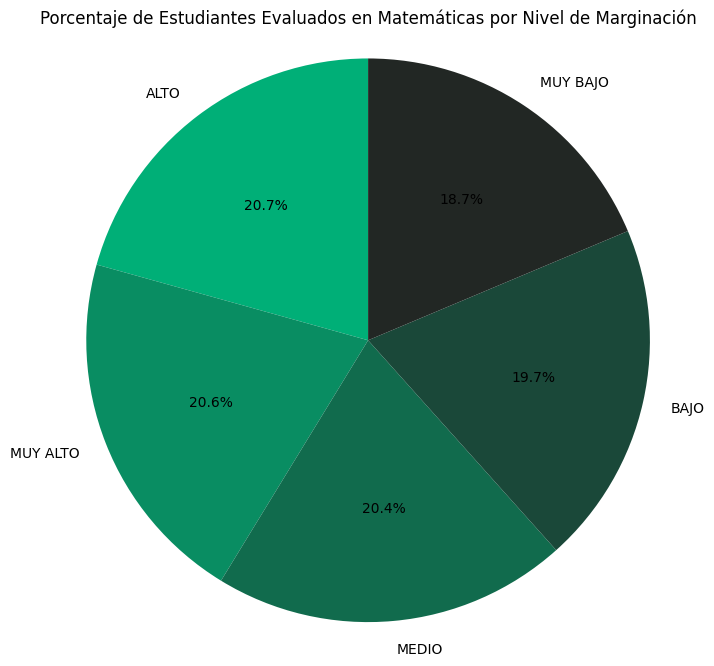

In [66]:

# Agrupar por el nivel de marginación y calcular el promedio de los porcentajes de evaluación en matemáticas
df_marginacion = df.groupby('GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT')['PORCENTAJE DE ALUMNOS EVALUADOS MATEMATICAS'].mean().sort_values(ascending=False)

# Crear paleta de colores personalizada
n_colors = len(df_marginacion)
verde_base = "#00af77"
palette_dark = sns.dark_palette(verde_base, n_colors=n_colors, reverse=True)

# Crear gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(df_marginacion, labels=df_marginacion.index, autopct='%1.1f%%', startangle=90, colors=palette_dark)
plt.title('Porcentaje de Estudiantes Evaluados en Matemáticas por Nivel de Marginación')
plt.axis('equal')  # Asegura que el gráfico sea circular
plt.show()

j) Del total de estudiantes en cada nivel de marginación, calcula y
grafica la proporción de estudiantes por nivel de logro en cada
una de las 2 áreas de conocimiento

<Figure size 1200x800 with 0 Axes>

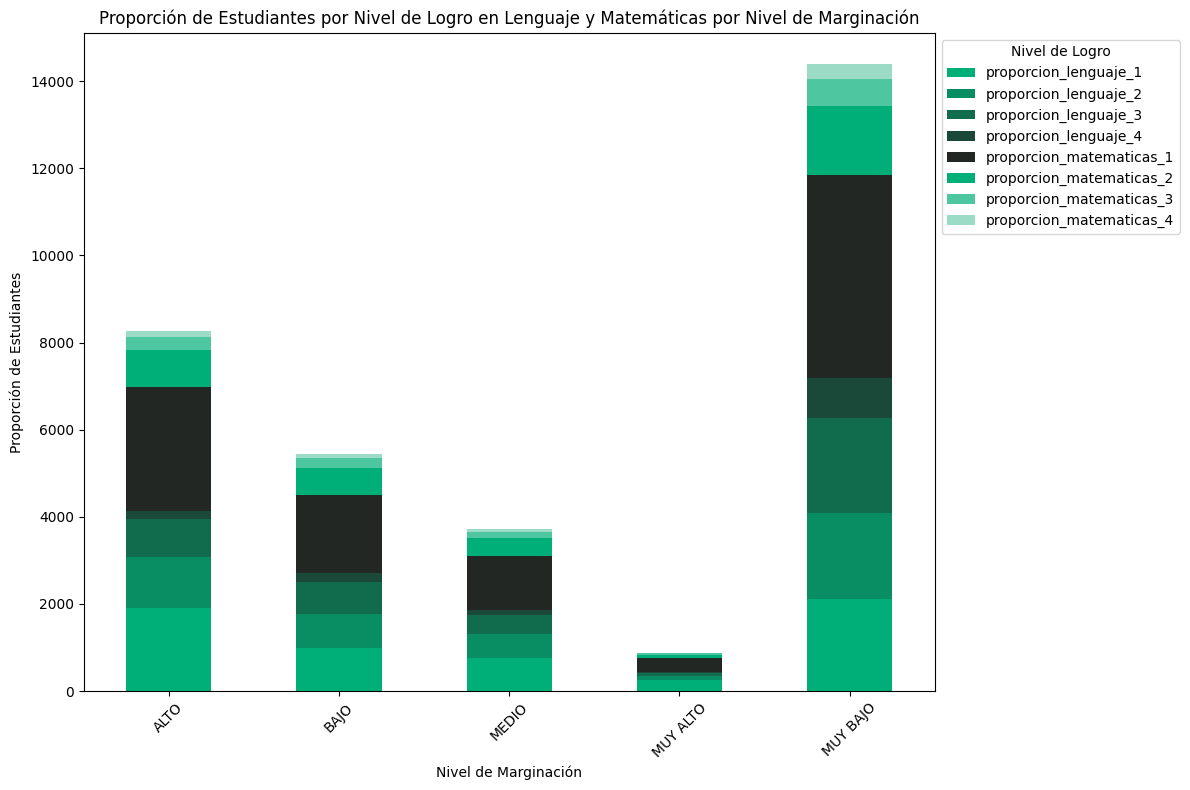

In [67]:



# Crear un DataFrame con las proporciones de los niveles de logro en Lenguaje y Matemáticas
df['total_alumnos'] = df[[
    'NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS',
    'NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS',
    'NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS',
    'NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS'
]].sum(axis=1)

# Rellenar valores NaN con 0 antes de la division.
df['total_alumnos'] = df['total_alumnos'].fillna(0)

# Calcular las proporciones para Lenguaje y Matemáticas en función del total de alumnos
df['proporcion_lenguaje_1'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION I PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)
df['proporcion_lenguaje_2'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION II PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)
df['proporcion_lenguaje_3'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION III PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)
df['proporcion_lenguaje_4'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)

df['proporcion_matematicas_1'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN MATEMATICAS I PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)
df['proporcion_matematicas_2'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN MATEMATICAS II PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)
df['proporcion_matematicas_3'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN MATEMATICAS III PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)
df['proporcion_matematicas_4'] = np.where(df['total_alumnos'] != 0, df['NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS'] / df['total_alumnos'], 0)

# Agrupar por nivel de marginación y calcular la proporción total de estudiantes en cada nivel de logro
df_marginacion = df.groupby('GRADO DE MARGINACIÓN CONAPO DE LA LOCALIDAD DONDE SE UBICA EL CT')[[
    'proporcion_lenguaje_1', 'proporcion_lenguaje_2', 'proporcion_lenguaje_3', 'proporcion_lenguaje_4',
    'proporcion_matematicas_1', 'proporcion_matematicas_2', 'proporcion_matematicas_3', 'proporcion_matematicas_4'
]].sum()

# Graficar las proporciones por nivel de marginación
plt.figure(figsize=(12, 8))

# Crear paleta de colores personalizada
n_colors = 8  # Número de niveles de logro
verde_base = "#00af77"
palette_dark = sns.dark_palette(verde_base, n_colors=n_colors // 2 + 1, reverse=True)
palette_light = sns.light_palette(verde_base, n_colors=n_colors // 2)[::-1]
palette = list(palette_dark) + list(palette_light)

ax = df_marginacion.plot(kind='bar', stacked=True, figsize=(12, 8), color=palette)

plt.title('Proporción de Estudiantes por Nivel de Logro en Lenguaje y Matemáticas por Nivel de Marginación')
plt.xlabel('Nivel de Marginación')
plt.ylabel('Proporción de Estudiantes')
plt.legend(title="Nivel de Logro", loc="upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A nivel Nacional:

Escuela con el mayor porcentaje de alumnos en Nivel 4 de Matemáticas.

Escuela con el menor porcentaje de alumnos en Nivel 4 de Matemáticas.

Escuela con el mayor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación.

Escuela con el menor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación.

In [68]:


# Escuela con el mayor porcentaje de alumnos en Nivel 4 de Matemáticas
nivel_4_matematicas_col = "NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS"
max_matematicas_nivel_4_row = df.loc[df[nivel_4_matematicas_col].idxmax()]
escuela_mayor_matematicas = max_matematicas_nivel_4_row['NOMBRE DE LA ESCUELA']
entidad_mayor_matematicas = max_matematicas_nivel_4_row['ENTIDAD']
clave_escuela_mayor_matematicas = max_matematicas_nivel_4_row['CLAVE DE LA ESCUELA']


# Escuela con el menor porcentaje de alumnos en Nivel 4 de Matemáticas
min_matematicas_nivel_4_row = df.loc[df[nivel_4_matematicas_col].idxmin()]
escuela_menor_matematicas = min_matematicas_nivel_4_row['NOMBRE DE LA ESCUELA']
entidad_menor_matematicas = min_matematicas_nivel_4_row['ENTIDAD']
clave_escuela_menor_matematicas = min_matematicas_nivel_4_row['CLAVE DE LA ESCUELA']

# Escuela con el mayor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación
nivel_4_lenguaje_col = "NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS"
max_lenguaje_nivel_4_row = df.loc[df[nivel_4_lenguaje_col].idxmax()]
escuela_mayor_lenguaje = max_lenguaje_nivel_4_row['NOMBRE DE LA ESCUELA']
entidad_mayor_lenguaje = max_lenguaje_nivel_4_row['ENTIDAD']

# Escuela con el menor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación
min_lenguaje_nivel_4_row = df.loc[df[nivel_4_lenguaje_col].idxmin()]
escuela_menor_lenguaje = min_lenguaje_nivel_4_row['NOMBRE DE LA ESCUELA']
entidad_menor_lenguaje = min_lenguaje_nivel_4_row['ENTIDAD']

print(f"Escuela con mayor porcentaje en Nivel 4 de Matemáticas: {escuela_mayor_matematicas}, {entidad_mayor_matematicas}, Clave de la escuela: {clave_escuela_mayor_matematicas}")
print(f"Escuela con menor porcentaje en Nivel 4 de Matemáticas: {escuela_menor_matematicas}, {entidad_menor_matematicas}, Clave de la escuela: {clave_escuela_menor_matematicas}")
print(f"Escuela con mayor porcentaje en Nivel 4 de Lenguaje y Comunicación: {escuela_mayor_lenguaje}, {entidad_mayor_lenguaje}")
print(f"Escuela con menor porcentaje en Nivel 4 de Lenguaje y Comunicación: {escuela_menor_lenguaje}, {entidad_menor_lenguaje}")


Escuela con mayor porcentaje en Nivel 4 de Matemáticas: TELEBACHILLERATO SANTA MARIA DE RAMOS, NUEVO LEON, Clave de la escuela: 19ETK0006H
Escuela con menor porcentaje en Nivel 4 de Matemáticas: ESC. PREP. ISAAC ARRIAGA, MICHOACAN, Clave de la escuela: 16UBH0014H
Escuela con mayor porcentaje en Nivel 4 de Lenguaje y Comunicación: FRAY BERNARDINO DE SAHAGUN, MICHOACAN
Escuela con menor porcentaje en Nivel 4 de Lenguaje y Comunicación: ESC. PREP. GRAL. LAZARO CARDENAS, MICHOACAN


En Oaxaca:

Escuela con el mayor porcentaje de alumnos en Nivel 4 de Matemáticas.

Escuela con el menor porcentaje de alumnos en Nivel 4 de Matemáticas.

Escuela con el mayor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación.

Escuela con el menor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación.

In [72]:

# Filtrar el DataFrame para incluir solo las filas donde la entidad es "OAXACA"
df_oaxaca = df[df['ENTIDAD'] == 'OAXACA']

# Escuela con el mayor porcentaje de alumnos en Nivel 4 de Matemáticas en Oaxaca
nivel_4_matematicas_col = "NIVELES DE LOGRO EN MATEMATICAS IV PORCENTAJE ALUMNOS"
if not df_oaxaca.empty:
  max_matematicas_nivel_4_row_oaxaca = df_oaxaca.loc[df_oaxaca[nivel_4_matematicas_col].idxmax()]
  escuela_mayor_matematicas_oaxaca = max_matematicas_nivel_4_row_oaxaca['NOMBRE DE LA ESCUELA']
  clave_escuela_mayor_matematicas_oaxaca = max_matematicas_nivel_4_row_oaxaca['CLAVE DE LA ESCUELA']
  print(f"Escuela con mayor porcentaje en Nivel 4 de Matemáticas en Oaxaca: {escuela_mayor_matematicas_oaxaca}, Clave de la escuela: {clave_escuela_mayor_matematicas_oaxaca}")
else:
  print("No hay datos para Oaxaca en el DataFrame.")


# Escuela con el menor porcentaje de alumnos en Nivel 4 de Matemáticas en Oaxaca
if not df_oaxaca.empty:
  min_matematicas_nivel_4_row_oaxaca = df_oaxaca.loc[df_oaxaca[nivel_4_matematicas_col].idxmin()]
  escuela_menor_matematicas_oaxaca = min_matematicas_nivel_4_row_oaxaca['NOMBRE DE LA ESCUELA']
  clave_escuela_menor_matematicas_oaxaca = min_matematicas_nivel_4_row_oaxaca['CLAVE DE LA ESCUELA']
  print(f"Escuela con menor porcentaje en Nivel 4 de Matemáticas en Oaxaca: {escuela_menor_matematicas_oaxaca}, Clave de la escuela: {clave_escuela_menor_matematicas_oaxaca}")
else:
  print("No hay datos para Oaxaca en el DataFrame.")


# Escuela con el mayor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación en Oaxaca
nivel_4_lenguaje_col = "NIVELES DE LOGRO EN LENGUAJE Y COMUNICACION IV PORCENTAJE ALUMNOS"
if not df_oaxaca.empty:
  max_lenguaje_nivel_4_row_oaxaca = df_oaxaca.loc[df_oaxaca[nivel_4_lenguaje_col].idxmax()]
  escuela_mayor_lenguaje_oaxaca = max_lenguaje_nivel_4_row_oaxaca['NOMBRE DE LA ESCUELA']
  clave_escuela_mayor_lenguaje_oaxaca = max_lenguaje_nivel_4_row_oaxaca['CLAVE DE LA ESCUELA']
  print(f"Escuela con mayor porcentaje en Nivel 4 de Lenguaje y Comunicación en Oaxaca: {escuela_mayor_lenguaje_oaxaca}, Clave de la escuela: {clave_escuela_mayor_lenguaje_oaxaca}")
else:
  print("No hay datos para Oaxaca en el DataFrame.")


# Escuela con el menor porcentaje de alumnos en Nivel 4 de Lenguaje y Comunicación en Oaxaca
if not df_oaxaca.empty:
  min_lenguaje_nivel_4_row_oaxaca = df_oaxaca.loc[df_oaxaca[nivel_4_lenguaje_col].idxmin()]
  escuela_menor_lenguaje_oaxaca = min_lenguaje_nivel_4_row_oaxaca['NOMBRE DE LA ESCUELA']
  clave_escuela_menor_lenguaje_oaxaca = min_lenguaje_nivel_4_row_oaxaca['CLAVE DE LA ESCUELA']
  print(f"Escuela con menor porcentaje en Nivel 4 de Lenguaje y Comunicación en Oaxaca: {escuela_menor_lenguaje_oaxaca}, Clave de la escuela: {clave_escuela_menor_lenguaje_oaxaca}")
else:
  print("No hay datos para Oaxaca en el DataFrame.")


Escuela con mayor porcentaje en Nivel 4 de Matemáticas en Oaxaca: PUENTE BARRA COPALITA, Clave de la escuela: 20ETH0237A
Escuela con menor porcentaje en Nivel 4 de Matemáticas en Oaxaca: ESCUELA DE BELLAS ARTES, Clave de la escuela: 20UAR0001Y
Escuela con mayor porcentaje en Nivel 4 de Lenguaje y Comunicación en Oaxaca: PLANTEL NUM. 27 LA MIXTEQUITA, Clave de la escuela: 20ETC0027A
Escuela con menor porcentaje en Nivel 4 de Lenguaje y Comunicación en Oaxaca: ESCUELA PREPARATORIA NUM. 1, Clave de la escuela: 20UBH0001Q
